# 04224 | Ôn tập tuần 1–2 — Dữ liệu mượn sách thư viện

Họ và tên: Nguyễn Đức Thịnh
MSSV: 2305CT2084  
Lớp: CT07PM

In [1]:
from pathlib import Path
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 50)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["font.size"] = 11

# Vòng lặp này chỉ chọn một tên font, không duyệt bản ghi.
available_fonts = {font.name for font in plt.matplotlib.font_manager.fontManager.ttflist}
for font_name in ("Segoe UI", "Arial", "Tahoma", "Times New Roman"):
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

DATA_RAW = Path("data") / "muon_sach_raw.csv"
DATA_CLEAN = Path("data") / "muon_sach_clean.csv"
if not DATA_RAW.exists():
    raise FileNotFoundError("Hãy chạy notebook tại thư mục chứa thư mục data.")

RAW_HASH = hashlib.sha256(DATA_RAW.read_bytes()).hexdigest()
COMBINING_MARKS = "".join(chr(code) for code in range(0x0300, 0x0370))
GENRE_MAP = {
    "kinh te": "Kinh tế",
    "ky thuat": "Kỹ thuật",
    "ngoai ngu": "Ngoại ngữ",
    "thieu nhi": "Thiếu nhi",
    "van hoc": "Văn học",
}
CAMPUS_MAP = {"co so 1": "Cơ sở 1", "co so 2": "Cơ sở 2", "co so 3": "Cơ sở 3"}
GENRE_COLORS = {
    "Kỹ thuật": "#1f4e79",
    "Kinh tế": "#2e75b6",
    "Văn học": "#5b9bd5",
    "Ngoại ngữ": "#ed7d31",
    "Thiếu nhi": "#70ad47",
}


def profile_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Hồ sơ cột: kiểu, số thiếu, tỷ lệ thiếu, số giá trị phân biệt, số dòng trùng hoàn toàn."""
    profile = pd.DataFrame(
        {
            "kieu_du_lieu": df.dtypes.astype(str),
            "so_luong_thieu": df.isna().sum().astype(int),
            "ty_le_thieu_%": (df.isna().mean() * 100).round(2),
            "so_gia_tri_phan_biet": df.nunique(dropna=True).astype(int),
        },
        index=df.columns,
    )
    # Một con số của cả bảng, lặp lại trên từng dòng để nằm trong giá trị trả về.
    profile["so_dong_trung_hoan_toan"] = int(df.duplicated().sum())
    return profile


def fold_text(series: pd.Series) -> pd.Series:
    text = series.astype("string").str.strip()
    text = text.str.replace("đ", "d", regex=False).str.replace("Đ", "D", regex=False)
    text = text.str.normalize("NFD").str.translate(str.maketrans("", "", COMBINING_MARKS))
    return text.str.replace(r"\s+", " ", regex=True).str.lower()


def parse_tien_phat(series: pd.Series) -> pd.Series:
    text = series.astype("string").str.strip()
    text = text.str.replace("đ", "", regex=False).str.replace("Đ", "", regex=False)
    text = text.str.replace(" ", "", regex=False).str.replace(".", "", regex=False)
    return pd.to_numeric(text, errors="coerce")


def parse_tien_phat_sai_thap_phan(series: pd.Series) -> pd.Series:
    text = series.astype("string").str.strip()
    text = text.str.replace("đ", "", regex=False).str.replace("Đ", "", regex=False)
    text = text.str.replace(" ", "", regex=False)
    return pd.to_numeric(text, errors="coerce")


def parse_ngay(series: pd.Series) -> pd.Series:
    text = series.astype("string").str.strip()
    parsed = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")
    iso = text.str.fullmatch(r"\d{4}-\d{2}-\d{2}").fillna(False)
    dmy = text.str.fullmatch(r"\d{2}/\d{2}/\d{4}").fillna(False)
    parsed.loc[iso] = pd.to_datetime(text.loc[iso], format="%Y-%m-%d", errors="coerce")
    parsed.loc[dmy] = pd.to_datetime(text.loc[dmy], format="%d/%m/%Y", errors="coerce")
    return parsed


def fmt_int(value) -> str:
    return f"{int(round(value)):,}".replace(",", ".")


def fmt_pct(value, digits: int = 1) -> str:
    return f"{value:.{digits}f}".replace(".", ",")


print("Sẵn sàng. Mã băm tệp thô đã lưu để kiểm tra cuối bài.")


Sẵn sàng. Mã băm tệp thô đã lưu để kiểm tra cuối bài.


## A. Nạp dữ liệu và lập hồ sơ

Mục tiêu: hiểu bảng trước khi sửa. Chưa ghi đè bất kỳ giá trị nào của `df_raw`.


### Câu 1. Giữ `ma_phieu` và `ma_the` là mã định danh

Đọc sao cho số 0 ở đầu `ma_the` không bị mất. Chứng minh điều đó ngay sau khi đọc.


In [2]:
df_raw = pd.read_csv(
    DATA_RAW,
    dtype={"ma_phieu": "string", "ma_the": "string"},
)
df_naive = pd.read_csv(DATA_RAW)

print("dtype ma_the khi ép chuỗi:", df_raw["ma_the"].dtype)
print("dtype ma_the khi để pandas tự suy:", df_naive["ma_the"].dtype)
print("Độ dài ma_the:")
print(df_raw["ma_the"].str.len().value_counts().sort_index())
print("Số mã khớp dạng 4 chữ số:", int(df_raw["ma_the"].str.fullmatch(r"\d{4}").sum()), "/", len(df_raw))

doi_chieu_ma = pd.DataFrame(
    {
        "ma_the_giu_chuoi": df_raw["ma_the"].head(8).astype(str),
        "ma_the_neu_doc_thanh_so": df_naive["ma_the"].head(8).astype(str),
    }
)
display(doi_chieu_ma)

mat_so_0 = int((df_raw["ma_the"].str.len() > df_naive["ma_the"].astype(str).str.len()).sum())
print(f"Nhận xét: Có {mat_so_0} mã bị cụt nếu đọc thành số. Ví dụ 0199 thành 199. Cột chuỗi vẫn đủ 4 ký tự, nên số 0 đầu còn nguyên.")


dtype ma_the khi ép chuỗi: string
dtype ma_the khi để pandas tự suy: int64
Độ dài ma_the:
ma_the
4    980
Name: count, dtype: Int64
Số mã khớp dạng 4 chữ số: 980 / 980


,ma_the_giu_chuoi,ma_the_neu_doc_thanh_so
0,0199,199
1,0466,466
2,0366,366
3,0058,58
4,0197,197
5,0269,269
6,0034,34
7,0190,190


Nhận xét: Có 980 mã bị cụt nếu đọc thành số. Ví dụ 0199 thành 199. Cột chuỗi vẫn đủ 4 ký tự, nên số 0 đầu còn nguyên.


### Câu 2. Kích thước, vài dòng đầu/cuối và kiểu dữ liệu


In [3]:
print(f"Số dòng: {df_raw.shape[0]}")
print(f"Số cột: {df_raw.shape[1]}")
print("Dòng đầu:")
display(df_raw.head())
print("Dòng cuối:")
display(df_raw.tail())
print("Kiểu dữ liệu:")
display(df_raw.dtypes.to_frame("kieu_du_lieu"))
print(
    "Nhận xét: ngay_muon và ngay_tra đang là chuỗi, trong khi nghiệp vụ cần ngày. "
    "tien_phat cũng là chuỗi vì có dạng như 21.000 đ. "
    "so_ngay_muon là số thực chỉ vì cột đang có giá trị thiếu; bản thân số ngày là số nguyên. "
    "so_lan_gia_han và muc_phat_ngay đã là số nguyên. ma_phieu và ma_the là chuỗi, đúng vai trò mã."
)


Số dòng: 980
Số cột: 10
Dòng đầu:


,ma_phieu,ma_the,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han,muc_phat_ngay,tien_phat
0,PM00026,0199,Thiếu nhi,Cơ sở 2,2024-05-07,2024-05-21,14.0,0,3000,0
1,PM00583,0466,Kinh tế,Cơ sở 1,2024-06-01,2024-06-16,15.0,0,3000,3000
2,PM00560,0366,Kỹ thuật,Cơ sở 2,2024-10-07,2024-10-30,23.0,1,7000,63000
3,PM00871,0058,Kinh tế,Cơ sở 2,2024-01-15,2024-02-05,21.0,1,3000,21.000 đ
4,PM00787,0197,Kinh tế,Cơ sở 1,2024-02-22,2024-03-05,12.0,0,3000,0


Dòng cuối:


,ma_phieu,ma_the,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han,muc_phat_ngay,tien_phat
975,PM00338,0091,Kỹ thuật,Cơ sở 1,2024-01-09,2024-01-31,22.0,1,7000,56.000 đ
976,PM00092,0249,Kỹ thuật,Cơ sở 1,2024-02-17,2024-03-06,18.0,1,7000,28.000 đ
977,PM00081,0041,Kỹ thuật,Cơ sở 1,02/06/2024,NaN,NaN,2,7000,NaN
978,PM00704,0345,Kinh tế,Cơ sở 1,2024-08-31,2024-09-22,22.0,1,3000,24000
979,PM00922,0095,Văn học,Cơ sở 1,17/03/2024,2024-04-02,16.0,0,3000,6000


Kiểu dữ liệu:


,kieu_du_lieu
ma_phieu,string
ma_the,string
the_loai,str
co_so,str
ngay_muon,str
ngay_tra,str
so_ngay_muon,float64
so_lan_gia_han,int64
muc_phat_ngay,int64
tien_phat,str


Nhận xét: ngay_muon và ngay_tra đang là chuỗi, trong khi nghiệp vụ cần ngày. tien_phat cũng là chuỗi vì có dạng như 21.000 đ. so_ngay_muon là số thực chỉ vì cột đang có giá trị thiếu; bản thân số ngày là số nguyên. so_lan_gia_han và muc_phat_ngay đã là số nguyên. ma_phieu và ma_the là chuỗi, đúng vai trò mã.


### Câu 3. Hàm `profile_dataframe`


In [4]:
ho_so_raw = profile_dataframe(df_raw)
display(ho_so_raw)
print(
    "Nhận xét: Cột so_dong_trung_hoan_toan là một con số của cả bảng, không phải của riêng từng cột. "
    f"Bảng có {int(df_raw.duplicated().sum())} dòng trùng hoàn toàn. "
    "Thiếu tập trung ở ngay_tra, so_ngay_muon và tien_phat. "
    "so_ngay_muon thiếu nhiều hơn ngay_tra, nên một phần phiếu đã có ngày trả vẫn mất số ngày."
)


,kieu_du_lieu,so_luong_thieu,ty_le_thieu_%,so_gia_tri_phan_biet,so_dong_trung_hoan_toan
ma_phieu,string,0,0.00,950,30
ma_the,string,0,0.00,380,30
the_loai,str,0,0.00,7,30
co_so,str,0,0.00,6,30
ngay_muon,str,0,0.00,435,30
ngay_tra,str,121,12.35,335,30
so_ngay_muon,float64,147,15.00,42,30
so_lan_gia_han,int64,0,0.00,4,30
muc_phat_ngay,int64,0,0.00,3,30
tien_phat,str,121,12.35,88,30


Nhận xét: Cột so_dong_trung_hoan_toan là một con số của cả bảng, không phải của riêng từng cột. Bảng có 30 dòng trùng hoàn toàn. Thiếu tập trung ở ngay_tra, so_ngay_muon và tien_phat. so_ngay_muon thiếu nhiều hơn ngay_tra, nên một phần phiếu đã có ngày trả vẫn mất số ngày.


### Câu 4. `ma_phieu` có duy nhất không?

Ba khái niệm: dòng trùng hoàn toàn, trùng mã nhưng giống nội dung, trùng mã nhưng mâu thuẫn nội dung.


In [5]:
so_ma = df_raw["ma_phieu"].nunique(dropna=False)
so_dong_trung = int(df_raw.duplicated().sum())
tan_suat_ma = df_raw.groupby("ma_phieu", dropna=False).size()
ma_lap = tan_suat_ma[tan_suat_ma > 1]
dong_ma_lap = df_raw[df_raw["ma_phieu"].isin(ma_lap.index)]
dong_thua_vi_trung_ma = int((ma_lap - 1).sum())
dong_thua_trung_hoan_toan = int(dong_ma_lap.duplicated().sum())
so_ma_mau_thuan = dong_thua_vi_trung_ma - dong_thua_trung_hoan_toan

print(f"Số dòng: {len(df_raw)}; số ma_phieu phân biệt: {so_ma}")
print(f"Số mã bị lặp: {len(ma_lap)}; số dòng thừa do lặp mã: {dong_thua_vi_trung_ma}")
print(f"Trong đó, dòng thừa trùng hoàn toàn: {dong_thua_trung_hoan_toan}")
print(f"Số dòng thừa cùng mã nhưng khác nội dung: {so_ma_mau_thuan}")
print(f"Dòng trùng hoàn toàn trên cả bảng: {so_dong_trung}")
print(
    "Nhận xét: ma_phieu chưa duy nhất. "
    "Dòng trùng hoàn toàn là mọi cột giống nhau, xóa được một cách tự động và giữ lại một bản. "
    "Trùng mã nhưng giống nội dung ở dữ liệu này chính là các dòng trùng hoàn toàn đó. "
    "Trùng mã nhưng mâu thuẫn nội dung là cùng mã mà nội dung khác nhau; không được tự động giữ dòng đầu. "
    "Hiện không có mã nào mâu thuẫn nội dung, nên chỉ cần bỏ dòng trùng hoàn toàn."
)


Số dòng: 980; số ma_phieu phân biệt: 950
Số mã bị lặp: 30; số dòng thừa do lặp mã: 30
Trong đó, dòng thừa trùng hoàn toàn: 30
Số dòng thừa cùng mã nhưng khác nội dung: 0
Dòng trùng hoàn toàn trên cả bảng: 30
Nhận xét: ma_phieu chưa duy nhất. Dòng trùng hoàn toàn là mọi cột giống nhau, xóa được một cách tự động và giữ lại một bản. Trùng mã nhưng giống nội dung ở dữ liệu này chính là các dòng trùng hoàn toàn đó. Trùng mã nhưng mâu thuẫn nội dung là cùng mã mà nội dung khác nhau; không được tự động giữ dòng đầu. Hiện không có mã nào mâu thuẫn nội dung, nên chỉ cần bỏ dòng trùng hoàn toàn.


### Câu 5. Tần số `the_loai` và `co_so`


In [6]:
print("Thể loại, kể cả cách viết:")
display(df_raw["the_loai"].value_counts(dropna=False).rename("so_luot").to_frame())
print("Cơ sở, in repr để thấy khoảng trắng:")
display(df_raw["co_so"].value_counts(dropna=False).rename("so_luot").to_frame())
print(f"Số cách viết the_loai: {df_raw['the_loai'].nunique(dropna=False)}")
print(f"Số cách viết co_so: {df_raw['co_so'].nunique(dropna=False)}")
print("Số nhóm sau khi gom hoa/thường, dấu và khoảng trắng:")
print("the_loai:", fold_text(df_raw["the_loai"]).nunique())
print("co_so:", fold_text(df_raw["co_so"]).nunique())
print(
    "Nhận xét: Dữ liệu có 7 cách viết thể loại nhưng nghiệp vụ chỉ có 5 nhóm. "
    "ky thuat là Kỹ thuật mất dấu; NGOẠI NGỮ là Ngoại ngữ viết hoa. "
    "Cơ sở có 6 cách viết nhưng chỉ có 3 cơ sở: dư khoảng trắng đầu/cuối và dạng CƠ SỞ 3."
)


Thể loại, kể cả cách viết:


,so_luot
the_loai,
Kinh tế,228
Văn học,228
Kỹ thuật,213
Ngoại ngữ,142
Thiếu nhi,106
ky thuat,37
NGOẠI NGỮ,26


Cơ sở, in repr để thấy khoảng trắng:


,so_luot
co_so,
Cơ sở 1,435
Cơ sở 2,278
Cơ sở 3,189
Cơ sở 1,47
Cơ sở 2,19
CƠ SỞ 3,12


Số cách viết the_loai: 7
Số cách viết co_so: 6
Số nhóm sau khi gom hoa/thường, dấu và khoảng trắng:
the_loai: 5
co_so: 3
Nhận xét: Dữ liệu có 7 cách viết thể loại nhưng nghiệp vụ chỉ có 5 nhóm. ky thuat là Kỹ thuật mất dấu; NGOẠI NGỮ là Ngoại ngữ viết hoa. Cơ sở có 6 cách viết nhưng chỉ có 3 cơ sở: dư khoảng trắng đầu/cuối và dạng CƠ SỞ 3.


### Câu 6. Mẫu ngày trong `ngay_muon` và `ngay_tra`

Chưa ghi kết quả chuyển đổi vào bảng. Phép thử bên dưới chỉ để kiểm tra lịch.


In [7]:
muon = df_raw["ngay_muon"].astype("string").str.strip()
tra = df_raw["ngay_tra"].astype("string").str.strip()
iso_muon = muon.str.fullmatch(r"\d{4}-\d{2}-\d{2}").fillna(False)
dmy_muon = muon.str.fullmatch(r"\d{2}/\d{2}/\d{4}").fillna(False)
iso_tra = tra.str.fullmatch(r"\d{4}-\d{2}-\d{2}").fillna(False)
dmy_tra = tra.str.fullmatch(r"\d{2}/\d{2}/\d{4}").fillna(False)

mau_ngay = pd.DataFrame(
    {
        "YYYY-MM-DD": [int(iso_muon.sum()), int(iso_tra.sum())],
        "DD/MM/YYYY": [int(dmy_muon.sum()), int(dmy_tra.sum())],
        "trong": [int(muon.isna().sum()), int(tra.isna().sum())],
        "mau_khac": [
            int((~iso_muon & ~dmy_muon & muon.notna()).sum()),
            int((~iso_tra & ~dmy_tra & tra.notna()).sum()),
        ],
    },
    index=["ngay_muon", "ngay_tra"],
)
display(mau_ngay)

thu_dmy = pd.to_datetime(muon[dmy_muon], format="%d/%m/%Y", errors="coerce")
ngay_khong_ton_tai = muon[dmy_muon][thu_dmy.isna()]
print("Chuỗi có dạng ngày nhưng không tồn tại trên lịch:")
display(ngay_khong_ton_tai.value_counts().rename("so_dong").to_frame())
print("dtype ngay_muon trong df_raw vẫn là:", df_raw["ngay_muon"].dtype)
print(
    "Nhận xét: Chỉ có hai mẫu, YYYY-MM-DD và DD/MM/YYYY. Không có mẫu lạ ngoài hai mẫu này. "
    "31/02/2024 đúng khuôn DD/MM/YYYY nhưng không phải ngày lịch: tháng 2 năm 2024 chỉ có 29 ngày. "
    "Ngày trả trống là thiếu giá trị, chưa thể kết luận là ngày sai."
)


,YYYY-MM-DD,DD/MM/YYYY,trong,mau_khac
ngay_muon,859,121,0,0
ngay_tra,859,0,121,0


Chuỗi có dạng ngày nhưng không tồn tại trên lịch:


,so_dong
ngay_muon,
31/02/2024,6


dtype ngay_muon trong df_raw vẫn là: str
Nhận xét: Chỉ có hai mẫu, YYYY-MM-DD và DD/MM/YYYY. Không có mẫu lạ ngoài hai mẫu này. 31/02/2024 đúng khuôn DD/MM/YYYY nhưng không phải ngày lịch: tháng 2 năm 2024 chỉ có 29 ngày. Ngày trả trống là thiếu giá trị, chưa thể kết luận là ngày sai.


### Câu 7. Miền giá trị các cột số và hàng rào IQR


In [8]:
print("so_ngay_muon:")
display(df_raw["so_ngay_muon"].describe().to_frame("so_ngay_muon"))
print("so_lan_gia_han:")
display(df_raw["so_lan_gia_han"].value_counts().sort_index().rename("so_dong").to_frame())
print("muc_phat_ngay:")
display(df_raw["muc_phat_ngay"].value_counts().sort_index().rename("so_dong").to_frame())
print("Vài giá trị tien_phat không phải số thuần:")
chuoi_tien = df_raw["tien_phat"].astype("string")
display(chuoi_tien[chuoi_tien.str.contains(r"[^0-9]", na=False)].value_counts().head(8).to_frame("so_dong"))

so_ngay = df_raw["so_ngay_muon"].dropna()
q1 = so_ngay.quantile(0.25)
q3 = so_ngay.quantile(0.75)
iqr = q3 - q1
hang_duoi = q1 - 1.5 * iqr
hang_tren = q3 + 1.5 * iqr
ngoai_iqr = so_ngay[(so_ngay < hang_duoi) | (so_ngay > hang_tren)]
print(f"Q1 = {q1}, Q3 = {q3}, IQR = {iqr}, hàng rào = [{hang_duoi}, {hang_tren}]")
print("Giá trị ngoài hàng rào:")
display(ngoai_iqr.value_counts().sort_index().rename("so_dong").to_frame())
print(
    "Nhận xét: Cần điều tra số ngày âm, số ngày rất lớn (66, 153, 217) và tiền phạt dạng chữ. "
    "Số lần gia hạn từ 0 đến 3 và mức phạt chỉ nhận 3000, 5000, 7000, nằm trong quy định. "
    "Một điểm ngoài hàng rào IQR chưa đủ để kết luận là sai. IQR chỉ tìm đuôi của phân phối. "
    "Một lượt mượn dài vẫn có thể đúng nếu khớp ngày trả trừ ngày mượn và khớp công thức phạt."
)


so_ngay_muon:


,so_ngay_muon
count,833.000000
mean,18.633854
std,11.294960
min,-21.000000
25%,13.000000
50%,18.000000
75%,23.000000
max,217.000000


so_lan_gia_han:


,so_dong
so_lan_gia_han,
0,372
1,471
2,133
3,4


muc_phat_ngay:


...

Vài giá trị tien_phat không phải số thuần:


,so_dong
tien_phat,
15.000 đ,13
12.000 đ,8
63.000 đ,7
9.000 đ,5
27.000 đ,5
6.000 đ,5
21.000 đ,4
70.000 đ,4


Q1 = 13.0, Q3 = 23.0, IQR = 10.0, hàng rào = [-2.0, 38.0]
Giá trị ngoài hàng rào:


,so_dong
so_ngay_muon,
-21.0,1
-13.0,1
-12.0,2
-9.0,1
66.0,1
153.0,1
217.0,1


Nhận xét: Cần điều tra số ngày âm, số ngày rất lớn (66, 153, 217) và tiền phạt dạng chữ. Số lần gia hạn từ 0 đến 3 và mức phạt chỉ nhận 3000, 5000, 7000, nằm trong quy định. Một điểm ngoài hàng rào IQR chưa đủ để kết luận là sai. IQR chỉ tìm đuôi của phân phối. Một lượt mượn dài vẫn có thể đúng nếu khớp ngày trả trừ ngày mượn và khớp công thức phạt.


### Câu 8. Kế hoạch làm sạch

Bốn cột: vấn đề, bằng chứng, ảnh hưởng, cách xử lý dự kiến. Chưa sửa dữ liệu.


In [9]:
ke_hoach = pd.DataFrame(
    [
        [
            "Dòng trùng hoàn toàn",
            "30 dòng thừa; mọi mã lặp đều giống nội dung",
            "Đếm lượt và tiền phạt bị cộng đôi",
            "drop_duplicates, rồi kiểm tra ma_phieu duy nhất",
        ],
        [
            "Nhãn thể loại không chuẩn",
            "7 cách viết, gom còn 5 khóa",
            "Một thể loại bị tách thành nhiều nhóm",
            "Xóa trắng, bỏ dấu, thống nhất hoa thường, map về 5 nhãn",
        ],
        [
            "Nhãn cơ sở không chuẩn",
            "Khoảng trắng và CƠ SỞ 3; 6 cách viết",
            "Tỷ lệ theo cơ sở bị lệch",
            "Chuẩn hóa về Cơ sở 1, Cơ sở 2, Cơ sở 3",
        ],
        [
            "tien_phat là chuỗi kiểu 63.000 đ",
            "Dấu chấm và hậu tố đ",
            "Coi chấm là thập phân sẽ thu nhỏ phạt khoảng 1.000 lần",
            "Bỏ đ và dấu chấm ngăn nghìn, rồi chuyển thành số",
        ],
        [
            "Hai khuôn ngày khác nhau",
            "YYYY-MM-DD và DD/MM/YYYY",
            "dayfirst chung có thể đảo tháng của ngày ISO",
            "Nhận từng mẫu và parse bằng format tường minh",
        ],
        [
            "Ngày 31/02/2024 không tồn tại",
            "Đúng khuôn nhưng ra NaT khi thử lịch",
            "Xóa dòng sẽ giảm tổng lượt; gán bừa sẽ sai tháng",
            "Giữ dòng, để ngày mượn là NaT, không đưa vào biểu đồ tháng",
        ],
        [
            "Phiếu chưa trả thiếu ngày trả, số ngày và tiền phạt",
            "Các cột này cùng trống khi không có ngày trả",
            "Điền số giả sẽ bịa phiếu đã trả và bịa tiền phạt",
            "Giữ giá trị thiếu, gắn trạng thái Đang mượn",
        ],
        [
            "Đã có hai ngày hợp lệ nhưng thiếu so_ngay_muon",
            "Tiền phạt khớp hiệu hai ngày",
            "Median sẽ gán nhầm độ dài cho từng phiếu",
            "Khôi phục so_ngay_muon = ngay_tra - ngay_muon",
        ],
        [
            "so_ngay_muon quá lớn so với hai ngày",
            "217, 153, 66 trong khi tiền phạt khớp số ngày ngắn",
            "Kéo trung bình và, nếu tính lại phạt, thổi tiền phạt",
            "Sửa số ngày theo hiệu hai ngày vì tiền phạt xác nhận",
        ],
        [
            "Ngày trả đứng trước ngày mượn",
            "Hiệu ngày âm và so_ngay_muon âm bằng hiệu đó",
            "Số ngày âm làm hỏng hạn 14 ngày",
            "Đảo hai ngày khi tiền phạt khớp trị tuyệt đối của số ngày",
        ],
    ],
    columns=["van_de", "bang_chung", "anh_huong", "cach_xu_ly_du_kien"],
)
display(ke_hoach)
print("Nhận xét: Bảng này là phương án. Mỗi bước ở phần B phải đối chiếu lại với bằng chứng, không làm sạch theo thói quen.")


,van_de,bang_chung,anh_huong,cach_xu_ly_du_kien
0,Dòng trùng hoàn toàn,30 dòng thừa; mọi mã lặp đều giống nội dung,Đếm lượt và tiền phạt bị cộng đôi,"drop_duplicates, rồi kiểm tra ma_phieu duy nhất"
1,Nhãn thể loại không chuẩn,"7 cách viết, gom còn 5 khóa",Một thể loại bị tách thành nhiều nhóm,"Xóa trắng, bỏ dấu, thống nhất hoa thường, map ..."
2,Nhãn cơ sở không chuẩn,Khoảng trắng và CƠ SỞ 3; 6 cách viết,Tỷ lệ theo cơ sở bị lệch,"Chuẩn hóa về Cơ sở 1, Cơ sở 2, Cơ sở 3"
3,tien_phat là chuỗi kiểu 63.000 đ,Dấu chấm và hậu tố đ,Coi chấm là thập phân sẽ thu nhỏ phạt khoảng 1...,"Bỏ đ và dấu chấm ngăn nghìn, rồi chuyển thành số"
4,Hai khuôn ngày khác nhau,YYYY-MM-DD và DD/MM/YYYY,dayfirst chung có thể đảo tháng của ngày ISO,Nhận từng mẫu và parse bằng format tường minh
5,Ngày 31/02/2024 không tồn tại,Đúng khuôn nhưng ra NaT khi thử lịch,Xóa dòng sẽ giảm tổng lượt; gán bừa sẽ sai tháng,"Giữ dòng, để ngày mượn là NaT, không đưa vào b..."
6,"Phiếu chưa trả thiếu ngày trả, số ngày và tiền...",Các cột này cùng trống khi không có ngày trả,Điền số giả sẽ bịa phiếu đã trả và bịa tiền phạt,"Giữ giá trị thiếu, gắn trạng thái Đang mượn"
7,Đã có hai ngày hợp lệ nhưng thiếu so_ngay_muon,Tiền phạt khớp hiệu hai ngày,Median sẽ gán nhầm độ dài cho từng phiếu,Khôi phục so_ngay_muon = ngay_tra - ngay_muon
8,so_ngay_muon quá lớn so với hai ngày,"217, 153, 66 trong khi tiền phạt khớp số ngày ...","Kéo trung bình và, nếu tính lại phạt, thổi tiề...",Sửa số ngày theo hiệu hai ngày vì tiền phạt xá...
9,Ngày trả đứng trước ngày mượn,Hiệu ngày âm và so_ngay_muon âm bằng hiệu đó,Số ngày âm làm hỏng hạn 14 ngày,Đảo hai ngày khi tiền phạt khớp trị tuyệt đối ...


Nhận xét: Bảng này là phương án. Mỗi bước ở phần B phải đối chiếu lại với bằng chứng, không làm sạch theo thói quen.


### Điểm dừng A

Đã có hồ sơ dữ liệu thô: kích thước, kiểu, thiếu, trùng, nhãn, mẫu ngày và miền số. Chưa gọi `dropna()` hay `fillna()` trên các cột thiếu vì chưa phân biệt thiếu theo nghiệp vụ với thiếu có thể khôi phục.


## B. Làm sạch có kiểm chứng — phần 1

Mục tiêu: sửa định dạng và nhãn, không làm mất dòng hợp lệ. Mọi bước làm trên `df_clean`.


### Câu 9. Bỏ dòng trùng hoàn toàn, rồi kiểm tra lại `ma_phieu`


In [10]:
df_clean = df_raw.drop_duplicates().copy()
print(f"Trước: {len(df_raw)} dòng. Sau khi bỏ trùng hoàn toàn: {len(df_clean)} dòng.")
print(f"ma_phieu duy nhất: {df_clean['ma_phieu'].nunique() == len(df_clean)}")
con_lap = df_clean["ma_phieu"].duplicated().sum()
print(f"Số mã vẫn lặp: {int(con_lap)}")
print(
    "Nhận xét: Sau bước này ma_phieu là duy nhất. "
    "Không có cặp cùng mã mà khác nội dung, nên không phải chọn dòng đầu một cách im lặng. "
    "df_raw vẫn giữ 980 dòng để so sánh."
)
assert len(df_raw) == 980
assert len(df_clean) == 950
assert df_clean["ma_phieu"].is_unique


Trước: 980 dòng. Sau khi bỏ trùng hoàn toàn: 950 dòng.
ma_phieu duy nhất: True
Số mã vẫn lặp: 0
Nhận xét: Sau bước này ma_phieu là duy nhất. Không có cặp cùng mã mà khác nội dung, nên không phải chọn dòng đầu một cách im lặng. df_raw vẫn giữ 980 dòng để so sánh.


### Câu 10. Chuẩn hóa `the_loai` và `co_so`


In [11]:
khoa_the_loai = fold_text(df_clean["the_loai"])
khoa_co_so = fold_text(df_clean["co_so"])
print("Khóa thể loại chưa có trong từ điển:", sorted(set(khoa_the_loai.dropna()) - set(GENRE_MAP)))
print("Khóa cơ sở chưa có trong từ điển:", sorted(set(khoa_co_so.dropna()) - set(CAMPUS_MAP)))

df_clean["the_loai"] = khoa_the_loai.map(GENRE_MAP)
df_clean["co_so"] = khoa_co_so.map(CAMPUS_MAP)

print("Thể loại sau chuẩn hóa:")
display(df_clean["the_loai"].value_counts().rename("so_luot").to_frame())
print("Cơ sở sau chuẩn hóa:")
display(df_clean["co_so"].value_counts().rename("so_luot").to_frame())
print(f"Số thể loại: {df_clean['the_loai'].nunique()} ; số giá trị thiếu: {int(df_clean['the_loai'].isna().sum())}")
print(f"Số cơ sở: {df_clean['co_so'].nunique()} ; số giá trị thiếu: {int(df_clean['co_so'].isna().sum())}")
print(
    "Nhận xét: Kiểm tra dùng ở đây là số nhóm đúng bằng 5 và 3, không còn giá trị thiếu sau map, "
    "và không còn khóa nào nằm ngoài từ điển. Map thất bại sẽ ra NA, nên điều kiện thiếu bằng 0 chứng minh không bỏ sót biến thể."
)
assert df_clean["the_loai"].nunique() == 5
assert df_clean["co_so"].nunique() == 3
assert df_clean["the_loai"].isna().sum() == 0
assert df_clean["co_so"].isna().sum() == 0


Khóa thể loại chưa có trong từ điển: []
Khóa cơ sở chưa có trong từ điển: []
Thể loại sau chuẩn hóa:


,so_luot
the_loai,
Kỹ thuật,246
Kinh tế,222
Văn học,219
Ngoại ngữ,160
Thiếu nhi,103


Cơ sở sau chuẩn hóa:


,so_luot
co_so,
Cơ sở 1,467
Cơ sở 2,288
Cơ sở 3,195


Số thể loại: 5 ; số giá trị thiếu: 0
Số cơ sở: 3 ; số giá trị thiếu: 0
Nhận xét: Kiểm tra dùng ở đây là số nhóm đúng bằng 5 và 3, không còn giá trị thiếu sau map, và không còn khóa nào nằm ngoài từ điển. Map thất bại sẽ ra NA, nên điều kiện thiếu bằng 0 chứng minh không bỏ sót biến thể.


### Câu 11. Chuyển `tien_phat` thành số

`63.000 đ` nghĩa là sáu mươi ba nghìn đồng. Dấu chấm ngăn hàng nghìn, chữ `đ` là đơn vị.


In [12]:
vi_du_tien = df_clean.loc[
    df_clean["tien_phat"].astype("string").str.contains("đ", na=False),
    ["ma_phieu", "so_ngay_muon", "muc_phat_ngay", "tien_phat"],
].head(5)
display(vi_du_tien)

chuoi_phat = df_clean["tien_phat"]
co_don_vi = chuoi_phat.astype("string").str.contains("đ", na=False)
dung = parse_tien_phat(chuoi_phat)
sai = parse_tien_phat_sai_thap_phan(chuoi_phat)
print(f"Số chuỗi có chữ đ: {int(co_don_vi.sum())}")
print(f"Tổng đúng của các chuỗi đó: {fmt_int(dung[co_don_vi].sum())} đồng")
print(f"Tổng nếu coi dấu chấm là thập phân: {fmt_int(sai[co_don_vi].sum())} đồng")
print(f"Tỷ số đúng/sai: {(dung[co_don_vi].sum() / sai[co_don_vi].sum()):.0f} lần")

df_clean["tien_phat"] = dung
print(
    "Nhận xét: 63.000 đ là 63000 đồng, không phải 63 đồng. "
    "Python đọc 63.000 thành 63.0. Với 105 phiếu sau khi loại trùng, 4.043.000 đồng bị thành 4.043 đồng, "
    "đúng 1.000 lần nhỏ hơn, và lệnh chuyển đổi không báo lỗi. Đó là sai số nghiêm trọng trên chỉ số tiền phạt."
)


,ma_phieu,so_ngay_muon,muc_phat_ngay,tien_phat
3,PM00871,21.0,3000,21.000 đ
5,PM00335,17.0,3000,9.000 đ
19,PM00823,23.0,7000,63.000 đ
25,PM00260,19.0,3000,15.000 đ
45,PM00626,24.0,7000,70.000 đ


Số chuỗi có chữ đ: 105
Tổng đúng của các chuỗi đó: 4.043.000 đồng
Tổng nếu coi dấu chấm là thập phân: 4.043 đồng


Tỷ số đúng/sai: 1000 lần
Nhận xét: 63.000 đ là 63000 đồng, không phải 63 đồng. Python đọc 63.000 thành 63.0. Với 105 phiếu sau khi loại trùng, 4.043.000 đồng bị thành 4.043 đồng, đúng 1.000 lần nhỏ hơn, và lệnh chuyển đổi không báo lỗi. Đó là sai số nghiêm trọng trên chỉ số tiền phạt.


### Câu 12. Chuyển hai cột ngày sang datetime, mỗi mẫu một format


In [13]:
ngay_muon_goc = df_clean["ngay_muon"].astype("string").copy()
ngay_tra_goc = df_clean["ngay_tra"].astype("string").copy()
df_clean["ngay_muon"] = parse_ngay(ngay_muon_goc)
df_clean["ngay_tra"] = parse_ngay(ngay_tra_goc)

vi_du = "2024-05-07"
print("Chuỗi ISO:", vi_du)
print("Format %Y-%m-%d:", pd.to_datetime(vi_du, format="%Y-%m-%d").date())
print("dayfirst=True, không chỉ format:", pd.to_datetime(vi_du, dayfirst=True).date())

iso_mask = ngay_muon_goc.str.fullmatch(r"\d{4}-\d{2}-\d{2}").fillna(False)
gia_tri_iso = pd.Series(ngay_muon_goc[iso_mask].dropna().unique())
doc_dung = pd.to_datetime(gia_tri_iso, format="%Y-%m-%d")
# dayfirst trên chuỗi ISO khiến parser đọc năm-ngày-tháng.
doc_nhu_dayfirst = pd.to_datetime(gia_tri_iso, format="%Y-%d-%m", errors="coerce")
am_tham = doc_nhu_dayfirst.notna() & doc_dung.ne(doc_nhu_dayfirst)
thanh_nat = doc_dung.notna() & doc_nhu_dayfirst.isna()
so_dong_am_tham = int(ngay_muon_goc.isin(set(gia_tri_iso[am_tham])).sum())
mau_dao = pd.DataFrame(
    {
        "chuoi_goc": gia_tri_iso[am_tham].head(5).to_numpy(),
        "format_%Y-%m-%d": doc_dung[am_tham].head(5).to_numpy(),
        "doc_nam_ngay_thang": doc_nhu_dayfirst[am_tham].head(5).to_numpy(),
    }
)
display(mau_dao)
print(f"Giá trị ISO bị đảo âm thầm: {int(am_tham.sum())}, ứng với {so_dong_am_tham} dòng ngày mượn")
print(f"Giá trị ISO thành NaT vì thành phần ngày lớn hơn 12: {int(thanh_nat.sum())}")
print(
    "Nhận xét: 2024-05-07 với format %Y-%m-%d là 7 tháng 5. "
    "Cùng chuỗi đó, dayfirst=True ra 5 tháng 7, vì cờ này kéo parser sang thứ tự năm-ngày-tháng. "
    "Cờ dayfirst chỉ dành cho chuỗi ngày/tháng/năm. Gắn một cờ cho cả cột ISO sẽ đổi tháng của mọi ngày có cả ngày và tháng không quá 12, mà không báo lỗi. "
    "Những ngày có thành phần ngày lớn hơn 12 thì mới thành NaT hoặc làm cả cột báo lỗi. Đó là lý do phải tách mẫu rồi parse bằng format tường minh."
)


Chuỗi ISO: 2024-05-07
Format %Y-%m-%d: 2024-05-07
dayfirst=True, không chỉ format: 2024-07-05


,chuoi_goc,format_%Y-%m-%d,doc_nam_ngay_thang
0,2024-05-07,2024-05-07,2024-07-05
1,2024-06-01,2024-06-01,2024-01-06
2,2024-10-07,2024-10-07,2024-07-10
3,2024-11-03,2024-11-03,2024-03-11
4,2024-10-11,2024-10-11,2024-11-10


Giá trị ISO bị đảo âm thầm: 121, ứng với 321 dòng ngày mượn
Giá trị ISO thành NaT vì thành phần ngày lớn hơn 12: 202
Nhận xét: 2024-05-07 với format %Y-%m-%d là 7 tháng 5. Cùng chuỗi đó, dayfirst=True ra 5 tháng 7, vì cờ này kéo parser sang thứ tự năm-ngày-tháng. Cờ dayfirst chỉ dành cho chuỗi ngày/tháng/năm. Gắn một cờ cho cả cột ISO sẽ đổi tháng của mọi ngày có cả ngày và tháng không quá 12, mà không báo lỗi. Những ngày có thành phần ngày lớn hơn 12 thì mới thành NaT hoặc làm cả cột báo lỗi. Đó là lý do phải tách mẫu rồi parse bằng format tường minh.


### Cảnh báo về ngày

Kết quả chạy không lỗi chưa chắc đã đúng. Với những ngày có cả ngày và tháng không quá 12, chuỗi gốc phải được đối chiếu với datetime.


In [14]:
hai_thanh_phan = ngay_muon_goc.str.extract(r"^(?P<nam>\d{4})-(?P<thang>\d{2})-(?P<ngay>\d{2})$")
ro_rang = iso_mask & hai_thanh_phan["thang"].notna()
thang = hai_thanh_phan.loc[ro_rang, "thang"].astype(int)
ngay = hai_thanh_phan.loc[ro_rang, "ngay"].astype(int)
can_doi = ro_rang.copy()
can_doi.loc[ro_rang] = (thang.le(12) & ngay.le(12) & thang.ne(ngay)).to_numpy()
mau_doi = df_clean.loc[can_doi, ["ma_phieu"]].copy()
mau_doi["chuoi_goc"] = ngay_muon_goc.loc[can_doi].to_numpy()
mau_doi["datetime"] = df_clean.loc[can_doi, "ngay_muon"]
mau_doi["khop_ngay"] = mau_doi["datetime"].dt.day.eq(mau_doi["chuoi_goc"].str.slice(8, 10).astype(int))
mau_doi["khop_thang"] = mau_doi["datetime"].dt.month.eq(mau_doi["chuoi_goc"].str.slice(5, 7).astype(int))
print(f"Số ngày ISO có cả ngày và tháng <= 12 và khác nhau: {int(can_doi.sum())}")
print(f"Khớp ngày: {int(mau_doi['khop_ngay'].sum())} / {len(mau_doi)}")
print(f"Khớp tháng: {int(mau_doi['khop_thang'].sum())} / {len(mau_doi)}")
display(mau_doi.head(5))
print("Nhận xét: Format tường minh giữ đúng ngày và tháng của chuỗi ISO. Đối chiếu này là kiểm tra độc lập, không chỉ dựa vào việc lệnh chạy xong.")
assert bool(mau_doi["khop_ngay"].all() and mau_doi["khop_thang"].all())


Số ngày ISO có cả ngày và tháng <= 12 và khác nhau: 321
Khớp ngày: 321 / 321
Khớp tháng: 321 / 321


,ma_phieu,chuoi_goc,datetime,khop_ngay,khop_thang
0,PM00026,2024-05-07,2024-05-07,True,True
1,PM00583,2024-06-01,2024-06-01,True,True
2,PM00560,2024-10-07,2024-10-07,True,True
7,PM00537,2024-11-03,2024-11-03,True,True
8,PM00895,2024-10-11,2024-10-11,True,True


Nhận xét: Format tường minh giữ đúng ngày và tháng của chuỗi ISO. Đối chiếu này là kiểm tra độc lập, không chỉ dựa vào việc lệnh chạy xong.


### Câu 13. Chuỗi nào thành NaT, và có nên loại bản ghi không?


In [15]:
muon_nat = df_clean["ngay_muon"].isna() & ngay_muon_goc.notna()
tra_nat = df_clean["ngay_tra"].isna() & ngay_tra_goc.notna()
print("Chuỗi ngày mượn thành NaT:")
display(ngay_muon_goc[muon_nat].value_counts().rename("so_dong").to_frame())
print(f"Số chuỗi ngày trả có mặt nhưng thành NaT: {int(tra_nat.sum())}")
print(f"Số dòng nếu giữ bản ghi: {len(df_clean)}")
print(f"Số dòng nếu loại ngày mượn không tồn tại: {len(df_clean) - int(muon_nat.sum())}")
print(
    "Nhận xét: Sáu chuỗi 31/02/2024 thành NaT. Ngày trả không có chuỗi nào sai lịch; chỗ trống là phiếu chưa trả. "
    "Chọn giữ bản ghi. Đây vẫn là một lượt mượn, số ngày và tiền phạt trên phiếu còn đối chiếu được với nhau. "
    "Tổng lượt vì vậy không giảm 6. Biểu đồ theo tháng không có tháng để đặt các phiếu này, nên chúng đứng ngoài biểu đồ, "
    "và giới hạn đó phải được ghi ở phần nhận xét. Xóa chúng sẽ làm tổng lượt và tỷ trọng thể loại nhỏ đi một chút mà không sửa được ngày."
)


Chuỗi ngày mượn thành NaT:


,so_dong
ngay_muon,
31/02/2024,6


Số chuỗi ngày trả có mặt nhưng thành NaT: 0
Số dòng nếu giữ bản ghi: 950
Số dòng nếu loại ngày mượn không tồn tại: 944
Nhận xét: Sáu chuỗi 31/02/2024 thành NaT. Ngày trả không có chuỗi nào sai lịch; chỗ trống là phiếu chưa trả. Chọn giữ bản ghi. Đây vẫn là một lượt mượn, số ngày và tiền phạt trên phiếu còn đối chiếu được với nhau. Tổng lượt vì vậy không giảm 6. Biểu đồ theo tháng không có tháng để đặt các phiếu này, nên chúng đứng ngoài biểu đồ, và giới hạn đó phải được ghi ở phần nhận xét. Xóa chúng sẽ làm tổng lượt và tỷ trọng thể loại nhỏ đi một chút mà không sửa được ngày.


## B. Làm sạch có kiểm chứng — phần 2

Thiếu có nghĩa nghiệp vụ thì giữ. Thiếu hoặc sai mà khôi phục được bằng quy tắc thì sửa, và phải có bằng chứng.


### Câu 14. Mặt nạ Đã trả và Đang mượn


In [16]:
da_tra = df_clean["ngay_tra"].notna()
dang_muon = df_clean["ngay_tra"].isna()
print(f"Đã trả: {int(da_tra.sum())}")
print(f"Đang mượn: {int(dang_muon.sum())}")
thieu_khi_dang_muon = pd.Series(
    {
        "thieu_ngay_tra": int(df_clean.loc[dang_muon, "ngay_tra"].isna().sum()),
        "thieu_so_ngay": int(df_clean.loc[dang_muon, "so_ngay_muon"].isna().sum()),
        "thieu_tien_phat": int(df_clean.loc[dang_muon, "tien_phat"].isna().sum()),
    }
)
display(thieu_khi_dang_muon.to_frame("so_dong"))
print(
    "Nhận xét: Không được điền ngày trả, số ngày hoặc tiền phạt giả cho phiếu đang mở. "
    "Sách chưa về thì chưa có ngày trả thật, chưa chốt số ngày giữ và chưa phát sinh tiền phạt theo công thức. "
    "Điền median hoặc 0 sẽ biến phiếu đang mượn thành phiếu đã trả, làm giảm tỷ lệ quá hạn đang mở và bịa tổng phạt."
)
assert int(df_clean.loc[dang_muon, "so_ngay_muon"].notna().sum()) == 0
assert int(df_clean.loc[dang_muon, "tien_phat"].notna().sum()) == 0


Đã trả: 833
Đang mượn: 117


,so_dong
thieu_ngay_tra,117
thieu_so_ngay,117
thieu_tien_phat,117


Nhận xét: Không được điền ngày trả, số ngày hoặc tiền phạt giả cho phiếu đang mở. Sách chưa về thì chưa có ngày trả thật, chưa chốt số ngày giữ và chưa phát sinh tiền phạt theo công thức. Điền median hoặc 0 sẽ biến phiếu đang mượn thành phiếu đã trả, làm giảm tỷ lệ quá hạn đang mở và bịa tổng phạt.


### Câu 15. Khôi phục `so_ngay_muon` khi đã có hai ngày hợp lệ


In [17]:
hieu_ngay = (df_clean["ngay_tra"] - df_clean["ngay_muon"]).dt.days
du_hai_ngay = hieu_ngay.notna()
thieu_so_ngay = du_hai_ngay & df_clean["so_ngay_muon"].isna()
phat_theo_hieu = np.maximum(0, hieu_ngay - 14) * df_clean["muc_phat_ngay"]
khop_phat = df_clean["tien_phat"].eq(phat_theo_hieu)
print(f"Phiếu đủ hai ngày hợp lệ nhưng thiếu số ngày: {int(thieu_so_ngay.sum())}")
print(f"Trong đó tiền phạt khớp hiệu ngày: {int((thieu_so_ngay & khop_phat).sum())}")
display(
    df_clean.loc[thieu_so_ngay, ["ma_phieu", "the_loai", "ngay_muon", "ngay_tra", "muc_phat_ngay", "tien_phat"]]
    .assign(so_ngay_khoi_phuc=hieu_ngay[thieu_so_ngay])
    .head(8)
)
trung_vi_so_ngay = df_clean["so_ngay_muon"].median()
print(f"Trung vị số ngày hiện có, nếu dùng fillna(median): {trung_vi_so_ngay}")
df_clean.loc[thieu_so_ngay, "so_ngay_muon"] = hieu_ngay.loc[thieu_so_ngay]
print(
    "Nhận xét: Hai ngày hợp lệ cho đúng một hiệu số, và tiền phạt đã khớp hiệu đó, nên đây là khôi phục chứ không phải ước lượng. "
    f"fillna(median) sẽ gán {trung_vi_so_ngay:g} ngày cho mọi chỗ trống, kể cả phiếu chỉ mượn 8 ngày hoặc phiếu mượn 37 ngày. "
    "Trung vị làm méo từng phiếu và không dùng được thông tin ngày đang có."
)
assert int(thieu_so_ngay.sum()) == 25
assert int((thieu_so_ngay & khop_phat).sum()) == 25


Phiếu đủ hai ngày hợp lệ nhưng thiếu số ngày: 25
Trong đó tiền phạt khớp hiệu ngày: 25


,ma_phieu,the_loai,ngay_muon,ngay_tra,muc_phat_ngay,tien_phat,so_ngay_khoi_phuc
20,PM00331,Văn học,2024-01-03,2024-01-15,3000,0,12.0
22,PM00431,Thiếu nhi,2024-08-29,2024-09-21,3000,27000,23.0
41,PM00108,Kỹ thuật,2024-10-13,2024-11-19,7000,161000,37.0
70,PM00180,Kỹ thuật,2024-11-10,2024-12-03,7000,63000,23.0
128,PM00203,Kinh tế,2024-06-20,2024-07-16,3000,36000,26.0
225,PM00619,Kinh tế,2024-02-05,2024-02-24,3000,15000,19.0
256,PM00388,Văn học,2024-11-13,2024-12-08,3000,33000,25.0
292,PM00370,Ngoại ngữ,2024-06-26,2024-07-08,5000,0,12.0


Trung vị số ngày hiện có, nếu dùng fillna(median): 18.0
Nhận xét: Hai ngày hợp lệ cho đúng một hiệu số, và tiền phạt đã khớp hiệu đó, nên đây là khôi phục chứ không phải ước lượng. fillna(median) sẽ gán 18 ngày cho mọi chỗ trống, kể cả phiếu chỉ mượn 8 ngày hoặc phiếu mượn 37 ngày. Trung vị làm méo từng phiếu và không dùng được thông tin ngày đang có.


### Câu 16. Ứng viên bất thường của `so_ngay_muon` theo IQR


In [18]:
so_ngay_hien_co = df_clean["so_ngay_muon"].dropna()
q1 = so_ngay_hien_co.quantile(0.25)
q3 = so_ngay_hien_co.quantile(0.75)
iqr = q3 - q1
hang_duoi = q1 - 1.5 * iqr
hang_tren = q3 + 1.5 * iqr
ngoai = df_clean["so_ngay_muon"].notna() & (
    df_clean["so_ngay_muon"].lt(hang_duoi) | df_clean["so_ngay_muon"].gt(hang_tren)
)
hieu_ngay = (df_clean["ngay_tra"] - df_clean["ngay_muon"]).dt.days
phat_theo_so = np.maximum(0, df_clean["so_ngay_muon"] - 14) * df_clean["muc_phat_ngay"]
phat_theo_hieu = np.maximum(0, hieu_ngay - 14) * df_clean["muc_phat_ngay"]
phat_theo_tri_tuyet_doi = np.maximum(0, hieu_ngay.abs() - 14) * df_clean["muc_phat_ngay"]

swap_mask = (
    hieu_ngay.notna()
    & hieu_ngay.lt(0)
    & df_clean["so_ngay_muon"].eq(hieu_ngay)
    & df_clean["tien_phat"].eq(phat_theo_tri_tuyet_doi)
)
typo_mask = (
    hieu_ngay.notna()
    & df_clean["so_ngay_muon"].notna()
    & df_clean["so_ngay_muon"].ne(hieu_ngay)
    & df_clean["tien_phat"].eq(phat_theo_hieu)
    & df_clean["tien_phat"].ne(phat_theo_so)
    & ~swap_mask
)
dai_hop_le = (
    hieu_ngay.notna()
    & df_clean["so_ngay_muon"].eq(hieu_ngay)
    & df_clean["tien_phat"].eq(phat_theo_hieu)
    & df_clean["so_ngay_muon"].ge(30)
)

dieu_tra = df_clean.loc[ngoai, ["ma_phieu", "the_loai", "so_lan_gia_han", "so_ngay_muon", "muc_phat_ngay", "tien_phat"]].copy()
dieu_tra["chuoi_muon"] = ngay_muon_goc.loc[ngoai].to_numpy()
dieu_tra["chuoi_tra"] = ngay_tra_goc.loc[ngoai].to_numpy()
dieu_tra["hieu_ngay"] = hieu_ngay.loc[ngoai].to_numpy()
dieu_tra["phat_theo_so_ngay"] = phat_theo_so.loc[ngoai].to_numpy()
dieu_tra["phat_theo_hieu_ngay"] = phat_theo_hieu.loc[ngoai].to_numpy()
dieu_tra["nhom"] = np.select(
    [swap_mask.loc[ngoai], typo_mask.loc[ngoai]],
    ["ngay_bi_dao", "loi_go_so_ngay"],
    default="chua_du_bang_chung",
)
print(f"Q1 = {q1}, Q3 = {q3}, IQR = {iqr}, hàng rào = [{hang_duoi}, {hang_tren}]")
print(f"Số ứng viên ngoài hàng rào: {int(ngoai.sum())}")
display(dieu_tra.sort_values("so_ngay_muon"))
print(f"Số phiếu từ 30 ngày trở lên mà số ngày và tiền phạt đều khớp hai ngày: {int(dai_hop_le.sum())}")
print(
    "Nhận xét: Hai nhóm ngoài hàng rào. "
    "Nhóm số ngày rất lớn: giả thuyết là gõ thừa chữ số. Bằng chứng là hiệu hai ngày ngắn hơn nhiều và tiền phạt khớp hiệu đó, không khớp số ngày đã ghi. "
    "Kết luận: đây là lỗi số ngày, chưa sửa tại câu này. "
    "Nhóm số ngày âm: giả thuyết là hai ngày bị đảo và số ngày mang dấu trừ. Bằng chứng là số ngày bằng đúng hiệu âm, còn tiền phạt khớp số ngày trị tuyệt đối. "
    "Kết luận: đây không phải lượt mượn âm. "
    "Các phiếu dài từ 30 ngày nếu khớp cả hai ràng buộc thì không nằm trong danh sách sửa, dù gần hàng rào. IQR chỉ lập danh sách ứng viên."
)


Q1 = 13.0, Q3 = 23.0, IQR = 10.0, hàng rào = [-2.0, 38.0]
Số ứng viên ngoài hàng rào: 7


,ma_phieu,the_loai,so_lan_gia_han,so_ngay_muon,muc_phat_ngay,tien_phat,chuoi_muon,chuoi_tra,hieu_ngay,phat_theo_so_ngay,phat_theo_hieu_ngay,nhom
638,PM00675,Ngoại ngữ,1,-21.0,5000,35000,2024-01-29,2024-01-08,-21.0,0.0,0.0,ngay_bi_dao
944,PM00327,Văn học,1,-13.0,3000,0,2024-11-10,2024-10-28,-13.0,0.0,0.0,ngay_bi_dao
372,PM00348,Văn học,0,-12.0,3000,0,2024-06-30,2024-06-18,-12.0,0.0,0.0,ngay_bi_dao
923,PM00336,Thiếu nhi,1,-9.0,3000,0,2024-06-08,2024-05-30,-9.0,0.0,0.0,ngay_bi_dao
504,PM00204,Kinh tế,0,66.0,3000,0,2024-12-18,2024-12-24,6.0,156000.0,0.0,loi_go_so_ngay
565,PM00796,Thiếu nhi,0,153.0,3000,3000,2024-01-23,2024-02-07,15.0,417000.0,3000.0,loi_go_so_ngay
929,PM00028,Thiếu nhi,0,217.0,3000,21000,2024-04-04,2024-04-25,21.0,609000.0,21000.0,loi_go_so_ngay


Số phiếu từ 30 ngày trở lên mà số ngày và tiền phạt đều khớp hai ngày: 49
Nhận xét: Hai nhóm ngoài hàng rào. Nhóm số ngày rất lớn: giả thuyết là gõ thừa chữ số. Bằng chứng là hiệu hai ngày ngắn hơn nhiều và tiền phạt khớp hiệu đó, không khớp số ngày đã ghi. Kết luận: đây là lỗi số ngày, chưa sửa tại câu này. Nhóm số ngày âm: giả thuyết là hai ngày bị đảo và số ngày mang dấu trừ. Bằng chứng là số ngày bằng đúng hiệu âm, còn tiền phạt khớp số ngày trị tuyệt đối. Kết luận: đây không phải lượt mượn âm. Các phiếu dài từ 30 ngày nếu khớp cả hai ràng buộc thì không nằm trong danh sách sửa, dù gần hàng rào. IQR chỉ lập danh sách ứng viên.


### Câu 17. Phân biệt lỗi gõ số ngày, đảo ngày, và lượt mượn dài hợp lệ

Sửa chỉ những dòng có bằng chứng ở câu 16.


In [19]:
print(f"Đảo ngày: {int(swap_mask.sum())} dòng. Mã: {df_clean.loc[swap_mask, 'ma_phieu'].tolist()}")
print(f"Lỗi gõ số ngày: {int(typo_mask.sum())} dòng. Mã: {df_clean.loc[typo_mask, 'ma_phieu'].tolist()}")
print(f"Lượt dài hợp lệ, giữ nguyên: {int(dai_hop_le.sum())} dòng. Số ngày lớn nhất trong nhóm này: {df_clean.loc[dai_hop_le, 'so_ngay_muon'].max()}")

ngay_muon_cu = df_clean.loc[swap_mask, "ngay_muon"].copy()
df_clean.loc[swap_mask, "ngay_muon"] = df_clean.loc[swap_mask, "ngay_tra"]
df_clean.loc[swap_mask, "ngay_tra"] = ngay_muon_cu
df_clean.loc[swap_mask, "so_ngay_muon"] = (
    df_clean.loc[swap_mask, "ngay_tra"] - df_clean.loc[swap_mask, "ngay_muon"]
).dt.days

hieu_sau_dao = (df_clean["ngay_tra"] - df_clean["ngay_muon"]).dt.days
df_clean.loc[typo_mask, "so_ngay_muon"] = hieu_sau_dao.loc[typo_mask]
print(
    "Nhận xét: Lỗi gõ số ngày là hai cột ngày đang đúng thứ tự, tiền phạt khớp hiệu ngày và không khớp số ngày đã gõ. "
    "Đảo ngày là ngày trả đứng trước ngày mượn, số ngày âm bằng đúng hiệu đó, tiền phạt lại khớp độ dài trị tuyệt đối. "
    "Lượt mượn dài hợp lệ là số ngày dương, bằng hiệu hai ngày, và tiền phạt đúng công thức; phiếu 30 ngày trở lên trong nhóm này được giữ. "
    "Ba tình huống dùng ba bằng chứng khác nhau, không gom thành một quy tắc xóa đuôi phân phối."
)


Đảo ngày: 4 dòng. Mã: ['PM00348', 'PM00675', 'PM00336', 'PM00327']
Lỗi gõ số ngày: 3 dòng. Mã: ['PM00204', 'PM00796', 'PM00028']
Lượt dài hợp lệ, giữ nguyên: 49 dòng. Số ngày lớn nhất trong nhóm này: 38.0
Nhận xét: Lỗi gõ số ngày là hai cột ngày đang đúng thứ tự, tiền phạt khớp hiệu ngày và không khớp số ngày đã gõ. Đảo ngày là ngày trả đứng trước ngày mượn, số ngày âm bằng đúng hiệu đó, tiền phạt lại khớp độ dài trị tuyệt đối. Lượt mượn dài hợp lệ là số ngày dương, bằng hiệu hai ngày, và tiền phạt đúng công thức; phiếu 30 ngày trở lên trong nhóm này được giữ. Ba tình huống dùng ba bằng chứng khác nhau, không gom thành một quy tắc xóa đuôi phân phối.


### Câu 18. Hai kiểm chứng chéo trên phiếu đã trả và có ngày hợp lệ

a) `so_ngay_muon == ngay_tra - ngay_muon`  
b) `tien_phat == max(0, so_ngay_muon - 14) * muc_phat_ngay`


In [20]:
hieu_ngay = (df_clean["ngay_tra"] - df_clean["ngay_muon"]).dt.days
phieu_kiem = df_clean["ngay_muon"].notna() & df_clean["ngay_tra"].notna()
phat_ky_vong = np.maximum(0, df_clean["so_ngay_muon"] - 14) * df_clean["muc_phat_ngay"]
khop_ngay = df_clean["so_ngay_muon"].eq(hieu_ngay)
khop_phat = df_clean["tien_phat"].eq(phat_ky_vong)
lech = phieu_kiem & ~(khop_ngay & khop_phat)

print(f"Phiếu đã trả và có đủ ngày hợp lệ: {int(phieu_kiem.sum())}")
print(f"Khớp số ngày: {int((phieu_kiem & khop_ngay).sum())}")
print(f"Khớp tiền phạt: {int((phieu_kiem & khop_phat).sum())}")
print(f"Số dòng còn lệch: {int(lech.sum())}")
if int(lech.sum()):
    display(df_clean.loc[lech, ["ma_phieu", "ngay_muon", "ngay_tra", "so_ngay_muon", "muc_phat_ngay", "tien_phat"]])

bon_phieu_khong_co_ngay_muon = df_clean["ngay_muon"].isna() & df_clean["ngay_tra"].notna()
print(f"Phiếu đã trả nhưng ngày mượn không hợp lệ, đứng ngoài hai kiểm chứng ngày: {int(bon_phieu_khong_co_ngay_muon.sum())}")
print(
    "Nhận xét: Nếu còn một dòng lệch, kiểm tra lại câu 12 trước, vì parse nhầm tháng làm hiệu ngày sai dù lệnh không báo lỗi. "
    "Sau đó kiểm tra câu 17, nơi giá trị số ngày và vị trí hai ngày bị sửa. "
    "Câu 15 chỉ điền chỗ trống nên ít khả năng tạo lệch mới nếu hiệu ngày đã đúng. "
    "Sáu phiếu 31/02/2024 không có ngày mượn hợp lệ nên không đưa vào mẫu kiểm chứng này; tiền phạt của chúng vẫn khớp số ngày đã ghi."
)
assert int(lech.sum()) == 0
assert int(phieu_kiem.sum()) == 827


Phiếu đã trả và có đủ ngày hợp lệ: 827
Khớp số ngày: 827
Khớp tiền phạt: 827
Số dòng còn lệch: 0
Phiếu đã trả nhưng ngày mượn không hợp lệ, đứng ngoài hai kiểm chứng ngày: 6
Nhận xét: Nếu còn một dòng lệch, kiểm tra lại câu 12 trước, vì parse nhầm tháng làm hiệu ngày sai dù lệnh không báo lỗi. Sau đó kiểm tra câu 17, nơi giá trị số ngày và vị trí hai ngày bị sửa. Câu 15 chỉ điền chỗ trống nên ít khả năng tạo lệch mới nếu hiệu ngày đã đúng. Sáu phiếu 31/02/2024 không có ngày mượn hợp lệ nên không đưa vào mẫu kiểm chứng này; tiền phạt của chúng vẫn khớp số ngày đã ghi.


### Câu 19. So sánh trước và sau làm sạch


In [21]:
def tom_tat(df: pd.DataFrame, ten: str) -> pd.Series:
    the_loai = df["the_loai"].astype("string")
    co_so = df["co_so"].astype("string")
    return pd.Series(
        {
            "so_dong": len(df),
            "so_cot": df.shape[1],
            "thieu_ngay_muon": int(df["ngay_muon"].isna().sum()),
            "thieu_ngay_tra": int(df["ngay_tra"].isna().sum()),
            "thieu_so_ngay": int(df["so_ngay_muon"].isna().sum()),
            "thieu_tien_phat": int(df["tien_phat"].isna().sum()),
            "so_nhan_the_loai": int(the_loai.nunique(dropna=True)),
            "so_nhan_co_so": int(co_so.nunique(dropna=True)),
            "so_ngay_min": df["so_ngay_muon"].min(),
            "so_ngay_max": df["so_ngay_muon"].max(),
        },
        name=ten,
    )


so_sanh = pd.concat([tom_tat(df_raw, "truoc"), tom_tat(df_clean, "sau")], axis=1)
so_sanh["thay_doi"] = so_sanh["sau"] - so_sanh["truoc"]
display(so_sanh)
print("Kiểu trước:")
display(df_raw.dtypes.to_frame("truoc").T)
print("Kiểu sau:")
display(df_clean.dtypes.to_frame("sau").T)
print(
    "Nhận xét: Chủ ý gồm giảm 30 dòng trùng, nhãn thể loại từ 7 về 5, nhãn cơ sở từ 6 về 3, "
    "đổi ngày sang datetime, đổi tiền phạt sang số, 6 ngày mượn không tồn tại thành thiếu, "
    "khôi phục 25 số ngày và sửa 4 phiếu đảo ngày cùng 3 phiếu gõ sai số ngày. "
    "Dấu hiệu làm mất dữ liệu sẽ là số dòng giảm quá 30, ma_phieu không còn duy nhất, "
    "thể loại hoặc cơ sở thành thiếu, hàng loạt ngày ISO thành NaT, hoặc tiền phạt nhỏ đi khoảng 1.000 lần. "
    "Các dấu hiệu đó không xuất hiện. Phiếu đang mượn vẫn thiếu ngày trả, số ngày và tiền phạt."
)


,truoc,sau,thay_doi
so_dong,980.0,950.0,-30.0
so_cot,10.0,10.0,0.0
thieu_ngay_muon,0.0,6.0,6.0
thieu_ngay_tra,121.0,117.0,-4.0
thieu_so_ngay,147.0,117.0,-30.0
thieu_tien_phat,121.0,117.0,-4.0
so_nhan_the_loai,7.0,5.0,-2.0
so_nhan_co_so,6.0,3.0,-3.0
so_ngay_min,-21.0,3.0,24.0
so_ngay_max,217.0,38.0,-179.0


Kiểu trước:


,ma_phieu,ma_the,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han,muc_phat_ngay,tien_phat
truoc,string,string,str,str,str,str,float64,int64,int64,str


Kiểu sau:


,ma_phieu,ma_the,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han,muc_phat_ngay,tien_phat
sau,string,string,str,str,datetime64[ns],datetime64[ns],float64,int64,int64,Int64


Nhận xét: Chủ ý gồm giảm 30 dòng trùng, nhãn thể loại từ 7 về 5, nhãn cơ sở từ 6 về 3, đổi ngày sang datetime, đổi tiền phạt sang số, 6 ngày mượn không tồn tại thành thiếu, khôi phục 25 số ngày và sửa 4 phiếu đảo ngày cùng 3 phiếu gõ sai số ngày. Dấu hiệu làm mất dữ liệu sẽ là số dòng giảm quá 30, ma_phieu không còn duy nhất, thể loại hoặc cơ sở thành thiếu, hàng loạt ngày ISO thành NaT, hoặc tiền phạt nhỏ đi khoảng 1.000 lần. Các dấu hiệu đó không xuất hiện. Phiếu đang mượn vẫn thiếu ngày trả, số ngày và tiền phạt.


### Câu 20. Lưu `data/muon_sach_clean.csv` và đọc lại từ đĩa


In [22]:
cot_luu = [
    "ma_phieu",
    "ma_the",
    "the_loai",
    "co_so",
    "ngay_muon",
    "ngay_tra",
    "so_ngay_muon",
    "so_lan_gia_han",
    "muc_phat_ngay",
    "tien_phat",
]
for cot_so in ("so_ngay_muon", "so_lan_gia_han", "muc_phat_ngay", "tien_phat"):
    df_clean[cot_so] = pd.to_numeric(df_clean[cot_so], errors="coerce").round().astype("Int64")

df_clean[cot_luu].to_csv(DATA_CLEAN, index=False, encoding="utf-8-sig", date_format="%Y-%m-%d")

doc_tho = pd.read_csv(DATA_CLEAN)
doc_lai = pd.read_csv(
    DATA_CLEAN,
    dtype={"ma_phieu": "string", "ma_the": "string"},
    parse_dates=["ngay_muon", "ngay_tra"],
)
for cot_so in ("so_ngay_muon", "so_lan_gia_han", "muc_phat_ngay", "tien_phat"):
    doc_lai[cot_so] = pd.to_numeric(doc_lai[cot_so], errors="coerce").round().astype("Int64")

print("Đọc ngây thơ, ma_the thành:", doc_tho["ma_the"].dtype, "; ví dụ:", doc_tho["ma_the"].iloc[0])
print("Đọc có chỉ định kiểu, ma_the:", doc_lai["ma_the"].iloc[0], "; độ dài 4:", bool(doc_lai["ma_the"].str.len().eq(4).all()))

hieu_file = (doc_lai["ngay_tra"] - doc_lai["ngay_muon"]).dt.days
kiem_file = doc_lai["ngay_muon"].notna() & doc_lai["ngay_tra"].notna()
khop_ngay_file = doc_lai["so_ngay_muon"].eq(hieu_file)
phat_file = np.maximum(0, doc_lai["so_ngay_muon"].astype("float") - 14) * doc_lai["muc_phat_ngay"].astype("float")
khop_phat_file = doc_lai["tien_phat"].astype("float").eq(phat_file)
print(f"Đọc lại từ file, phiếu kiểm: {int(kiem_file.sum())}")
print(f"Khớp số ngày: {int((kiem_file & khop_ngay_file).sum())}")
print(f"Khớp tiền phạt: {int((kiem_file & khop_phat_file).sum())}")
print("File thô còn nguyên:", hashlib.sha256(DATA_RAW.read_bytes()).hexdigest() == RAW_HASH)
print(
    "Nhận xét: Kiểm tra DataFrame trong bộ nhớ chưa đủ vì CSV không lưu kiểu của pandas. "
    "Đọc lại theo kiểu tự suy biến ma_the thành số và làm mất số 0 đầu, đồng thời đưa ngày về chuỗi. "
    "Lỗi này chỉ hiện khi mở lại tệp vừa ghi. Bước đọc lại cũng phát hiện việc ghi nhầm đường dẫn hoặc ghi đè tệp thô."
)
assert bool(doc_lai["ma_the"].str.fullmatch(r"\d{4}").all())
assert int((kiem_file & khop_ngay_file & khop_phat_file).sum()) == int(kiem_file.sum())
assert hashlib.sha256(DATA_RAW.read_bytes()).hexdigest() == RAW_HASH


Đọc ngây thơ, ma_the thành: int64 ; ví dụ: 199
Đọc có chỉ định kiểu, ma_the: 0199 ; độ dài 4: True
Đọc lại từ file, phiếu kiểm: 827
Khớp số ngày: 827
Khớp tiền phạt: 827
File thô còn nguyên: True
Nhận xét: Kiểm tra DataFrame trong bộ nhớ chưa đủ vì CSV không lưu kiểu của pandas. Đọc lại theo kiểu tự suy biến ma_the thành số và làm mất số 0 đầu, đồng thời đưa ngày về chuỗi. Lỗi này chỉ hiện khi mở lại tệp vừa ghi. Bước đọc lại cũng phát hiện việc ghi nhầm đường dẫn hoặc ghi đè tệp thô.


### Điểm dừng B

Mọi phiếu đã trả và có đủ ngày hợp lệ vượt qua cả hai kiểm chứng. Phiếu đang mượn vẫn thiếu ngày trả, số ngày và tiền phạt.


## C. Tạo biến và phân tích

Ưu tiên phép vector hóa. Không duyệt từng bản ghi bằng `for`, `iterrows()` hay `apply(axis=1)`.


In [23]:
df_clean["so_ngay_tre"] = (df_clean["so_ngay_muon"].astype("float") - 14).clip(lower=0)
df_clean["so_ngay_tre"] = df_clean["so_ngay_tre"].round().astype("Int64")
df_clean["trang_thai"] = np.where(df_clean["ngay_tra"].notna(), "Đã trả", "Đang mượn")
df_clean["thang_muon"] = df_clean["ngay_muon"].dt.to_period("M").dt.to_timestamp()

hop_le = df_clean["trang_thai"].eq("Đã trả") & df_clean["ngay_muon"].notna() & df_clean["ngay_tra"].notna()
print(f"Đã trả: {int(df_clean['trang_thai'].eq('Đã trả').sum())}")
print(f"Đang mượn: {int(df_clean['trang_thai'].eq('Đang mượn').sum())}")
print(f"Đã trả và có ngày hợp lệ: {int(hop_le.sum())}")


Đã trả: 833
Đang mượn: 117
Đã trả và có ngày hợp lệ: 827


### Câu 21. Miền giá trị của `so_ngay_tre`, `trang_thai`, `thang_muon`


In [24]:
print("so_ngay_tre trên phiếu đã có số ngày:")
display(df_clean["so_ngay_tre"].describe().to_frame("so_ngay_tre"))
print("Trạng thái:")
display(df_clean["trang_thai"].value_counts().rename("so_dong").to_frame())
print("Tháng mượn:")
display(df_clean["thang_muon"].value_counts().sort_index().rename("so_luot").to_frame())
print(f"Thiếu so_ngay_tre: {int(df_clean['so_ngay_tre'].isna().sum())}")
print(f"Thiếu thang_muon: {int(df_clean['thang_muon'].isna().sum())}")
print(f"so_ngay_tre nhỏ nhất của phiếu đã trả: {df_clean.loc[df_clean['trang_thai'].eq('Đã trả'), 'so_ngay_tre'].min()}")
print(
    "Nhận xét: so_ngay_tre không âm. Phiếu đang mượn không có số ngày nên số ngày trễ cũng thiếu, không bị gán 0. "
    "trang_thai chỉ có Đã trả và Đang mượn. thang_muon phủ 12 tháng năm 2024; 6 phiếu ngày mượn không tồn tại không có tháng."
)
assert df_clean["trang_thai"].isin(["Đã trả", "Đang mượn"]).all()
assert int(df_clean.loc[df_clean["trang_thai"].eq("Đang mượn"), "so_ngay_tre"].notna().sum()) == 0


so_ngay_tre trên phiếu đã có số ngày:


,so_ngay_tre
count,833.0
mean,5.578631
std,5.497497
min,0.0
25%,0.0
50%,4.0
75%,9.0
max,24.0


Trạng thái:


,so_dong
trang_thai,
Đã trả,833
Đang mượn,117


Tháng mượn:


,so_luot
thang_muon,
2024-01-01,74
2024-02-01,75
2024-03-01,87
2024-04-01,73
2024-05-01,80
2024-06-01,79
2024-07-01,74
2024-08-01,78
2024-09-01,77


Thiếu so_ngay_tre: 117
Thiếu thang_muon: 6
so_ngay_tre nhỏ nhất của phiếu đã trả: 0
Nhận xét: so_ngay_tre không âm. Phiếu đang mượn không có số ngày nên số ngày trễ cũng thiếu, không bị gán 0. trang_thai chỉ có Đã trả và Đang mượn. thang_muon phủ 12 tháng năm 2024; 6 phiếu ngày mượn không tồn tại không có tháng.


### Câu 22. Thể loại có nhiều lượt mượn nhất


In [25]:
dem_the_loai = df_clean["the_loai"].value_counts()
ty_trong = (dem_the_loai / dem_the_loai.sum() * 100).round(2)
bang_luot = pd.DataFrame({"so_luot": dem_the_loai, "ty_trong_%": ty_trong})
display(bang_luot)

co_ngay_muon = df_clean["ngay_muon"].notna()
dem_bo_ngay_loi = df_clean.loc[co_ngay_muon, "the_loai"].value_counts()
ty_trong_bo = (dem_bo_ngay_loi / dem_bo_ngay_loi.sum() * 100).round(2)
bang_bo = pd.DataFrame({"so_luot": dem_bo_ngay_loi, "ty_trong_%": ty_trong_bo})
print("Nếu bỏ phiếu không có ngày mượn hợp lệ:")
display(bang_bo)
print(
    f"Nhận xét: {dem_the_loai.index[0]} nhiều nhất, {int(dem_the_loai.iloc[0])} lượt, "
    f"chiếm {ty_trong.iloc[0]:.2f}% của {int(dem_the_loai.sum())} phiếu. "
    f"Bỏ {int((~co_ngay_muon).sum())} ngày mượn không hợp lệ thì nhóm đầu vẫn là {dem_bo_ngay_loi.index[0]}, "
    f"{int(dem_bo_ngay_loi.iloc[0])} trên {int(dem_bo_ngay_loi.sum())} lượt ({ty_trong_bo.iloc[0]:.2f}%). "
    "Thứ hạng không đổi vì sáu phiếu lỗi nằm rải ở vài thể loại, không đủ để soán nhóm dẫn đầu."
)


,so_luot,ty_trong_%
the_loai,,
Kỹ thuật,246,25.89
Kinh tế,222,23.37
Văn học,219,23.05
Ngoại ngữ,160,16.84
Thiếu nhi,103,10.84


Nếu bỏ phiếu không có ngày mượn hợp lệ:


,so_luot,ty_trong_%
the_loai,,
Kỹ thuật,243,25.74
Kinh tế,221,23.41
Văn học,219,23.20
Ngoại ngữ,159,16.84
Thiếu nhi,102,10.81


Nhận xét: Kỹ thuật nhiều nhất, 246 lượt, chiếm 25.89% của 950 phiếu. Bỏ 6 ngày mượn không hợp lệ thì nhóm đầu vẫn là Kỹ thuật, 243 trên 944 lượt (25.74%). Thứ hạng không đổi vì sáu phiếu lỗi nằm rải ở vài thể loại, không đủ để soán nhóm dẫn đầu.


### Câu 23. Trung vị và khoảng tứ phân vị của số ngày mượn theo thể loại


In [26]:
nhom_ngay = df_clean.loc[hop_le].groupby("the_loai")["so_ngay_muon"]
tu_phan_vi = pd.DataFrame(
    {
        "so_phieu": nhom_ngay.size(),
        "trung_vi": nhom_ngay.median(),
        "q1": nhom_ngay.quantile(0.25),
        "q3": nhom_ngay.quantile(0.75),
        "trung_binh": nhom_ngay.mean().round(2),
    }
).sort_values("trung_vi", ascending=False)
tu_phan_vi["khoang_tu_phan_vi"] = tu_phan_vi["q3"] - tu_phan_vi["q1"]
display(tu_phan_vi)
do_lech = float(df_clean.loc[hop_le, "so_ngay_muon"].astype(float).skew())
print(
    f"Nhận xét: Trung vị phù hợp hơn trung bình khi phân phối lệch hoặc có vài phiếu rất dài, vì trung bình bị những điểm đó kéo. "
    f"Trước khi sửa, các giá trị 217, 153 và 66 đang làm việc đó. Sau khi sửa, độ lệch còn {do_lech:.3f}, gần đối xứng, "
    "nên trung bình và trung vị xấp xỉ nhau. Trung vị và khoảng tứ phân vị vẫn là cặp cần báo cáo vì không phụ thuộc vào việc có giữ một phiếu dài hợp lệ hay không."
)


,so_phieu,trung_vi,q1,q3,trung_binh,khoang_tu_phan_vi
the_loai,,,,,,
Kỹ thuật,197,24.0,21.0,29.0,24.19,8.0
Ngoại ngữ,135,20.0,15.0,23.0,19.14,8.0
Kinh tế,201,17.0,13.0,21.0,17.27,8.0
Văn học,199,16.0,12.0,20.0,16.12,8.0
Thiếu nhi,95,13.0,7.0,16.0,12.28,9.0


Nhận xét: Trung vị phù hợp hơn trung bình khi phân phối lệch hoặc có vài phiếu rất dài, vì trung bình bị những điểm đó kéo. Trước khi sửa, các giá trị 217, 153 và 66 đang làm việc đó. Sau khi sửa, độ lệch còn 0.005, gần đối xứng, nên trung bình và trung vị xấp xỉ nhau. Trung vị và khoảng tứ phân vị vẫn là cặp cần báo cáo vì không phụ thuộc vào việc có giữ một phiếu dài hợp lệ hay không.


### Câu 24. Cơ sở có tỷ lệ phiếu Đang mượn cao nhất


In [27]:
bang_trang_thai = pd.crosstab(df_clean["co_so"], df_clean["trang_thai"])
bang_trang_thai["tong_phieu"] = bang_trang_thai.sum(axis=1)
bang_trang_thai["ty_le_dang_muon"] = bang_trang_thai["Đang mượn"] / bang_trang_thai["tong_phieu"]
bang_trang_thai = bang_trang_thai.sort_values("ty_le_dang_muon", ascending=False)
display(bang_trang_thai)
print("Xếp theo số phiếu đang mượn, không theo tỷ lệ:")
display(bang_trang_thai["Đang mượn"].sort_values(ascending=False).to_frame())
print(
    f"Nhận xét: {bang_trang_thai.index[0]} có tỷ lệ Đang mượn cao nhất, "
    f"{bang_trang_thai.iloc[0]['Đang mượn']:.0f}/{bang_trang_thai.iloc[0]['tong_phieu']:.0f} = {bang_trang_thai.iloc[0]['ty_le_dang_muon']:.1%}. "
    "Cơ sở 2 có nhiều phiếu đang mượn hơn Cơ sở 3, nhưng tỷ lệ lại thấp hơn vì mẫu số của Cơ sở 2 lớn hơn. "
    "So số tuyệt đối sẽ đổi thứ hạng của hai cơ sở này."
)


trang_thai,Đang mượn,Đã trả,tong_phieu,ty_le_dang_muon
co_so,,,,
Cơ sở 1,65,402,467,0.139186
Cơ sở 3,22,173,195,0.112821
Cơ sở 2,30,258,288,0.104167


Xếp theo số phiếu đang mượn, không theo tỷ lệ:


,Đang mượn
co_so,
Cơ sở 1,65
Cơ sở 2,30
Cơ sở 3,22


Nhận xét: Cơ sở 1 có tỷ lệ Đang mượn cao nhất, 65/467 = 13.9%. Cơ sở 2 có nhiều phiếu đang mượn hơn Cơ sở 3, nhưng tỷ lệ lại thấp hơn vì mẫu số của Cơ sở 2 lớn hơn. So số tuyệt đối sẽ đổi thứ hạng của hai cơ sở này.


### Câu 25. Số lần gia hạn và thời gian mượn


In [28]:
phieu_co_so_ngay = df_clean["trang_thai"].eq("Đã trả") & df_clean["so_ngay_muon"].notna()
bang_gia_han = (
    df_clean.loc[phieu_co_so_ngay]
    .groupby("so_lan_gia_han")["so_ngay_muon"]
    .agg(so_phieu="size", trung_vi="median", trung_binh="mean")
    .round(2)
)
display(bang_gia_han)
cap = df_clean.loc[phieu_co_so_ngay, ["so_lan_gia_han", "so_ngay_muon"]].astype(float)
pearson = float(cap.corr(method="pearson").iloc[0, 1])
spearman = float(cap.corr(method="spearman").iloc[0, 1])
print(f"Pearson: {pearson:.3f}")
print(f"Spearman: {spearman:.3f}")
print(
    "Nhận xét: Số ngày giữ tăng cùng số lần gia hạn. Spearman phù hợp hơn vì số lần gia hạn là thứ bậc rời rạc và ta chỉ cần quan hệ đơn điệu. "
    f"Hệ số khoảng {spearman:.2f} là tương quan thuận khá chặt trên phiếu đã trả. "
    "Tương quan không chứng minh nhân quả. Nội quy cho phép gia hạn để giữ sách lâu hơn, nên số ngày dài vừa là điều kiện vừa là kết quả của việc gia hạn. "
    f"Nhóm gia hạn 3 lần chỉ có {int(bang_gia_han.loc[3, 'so_phieu']) if 3 in bang_gia_han.index else 0} phiếu, trung vị của nhóm này chưa ổn định."
)


,so_phieu,trung_vi,trung_binh
so_lan_gia_han,,,
0,319,12.0,12.3
1,404,21.0,20.64
2,106,28.0,27.6
3,4,31.5,32.5


Pearson: 0.751
Spearman: 0.757
Nhận xét: Số ngày giữ tăng cùng số lần gia hạn. Spearman phù hợp hơn vì số lần gia hạn là thứ bậc rời rạc và ta chỉ cần quan hệ đơn điệu. Hệ số khoảng 0.76 là tương quan thuận khá chặt trên phiếu đã trả. Tương quan không chứng minh nhân quả. Nội quy cho phép gia hạn để giữ sách lâu hơn, nên số ngày dài vừa là điều kiện vừa là kết quả của việc gia hạn. Nhóm gia hạn 3 lần chỉ có 4 phiếu, trung vị của nhóm này chưa ổn định.


### Câu 26. Tổng tiền phạt và tiền phạt trung bình theo thể loại


In [29]:
da_tra_mask = df_clean["trang_thai"].eq("Đã trả")
phat_the_loai = (
    df_clean.loc[da_tra_mask]
    .groupby("the_loai")["tien_phat"]
    .agg(so_phieu="size", tong_tien_phat="sum", tien_phat_trung_binh="mean")
)
phat_the_loai["hang_theo_tong"] = phat_the_loai["tong_tien_phat"].rank(ascending=False).astype(int)
phat_the_loai["hang_theo_trung_binh"] = phat_the_loai["tien_phat_trung_binh"].rank(ascending=False).astype(int)
phat_the_loai = phat_the_loai.sort_values("tong_tien_phat", ascending=False)
display(phat_the_loai)
cung_hang = bool(phat_the_loai["hang_theo_tong"].eq(phat_the_loai["hang_theo_trung_binh"]).all())
print(
    "Nhận xét: Hai thước đo cho cùng một thứ hạng: Kỹ thuật, Ngoại ngữ, Kinh tế, Văn học, Thiếu nhi. "
    if cung_hang
    else "Nhận xét: Hai thước đo không cùng thứ hạng. "
)
print(
    "Tổng phạt bằng số phiếu nhân mức phạt mỗi phiếu, nên một nhóm đông nhưng phạt nhẹ có thể vượt một nhóm ít nhưng phạt nặng. "
    "Ở dữ liệu này khoảng cách mức phạt mỗi phiếu đủ lớn để số phiếu không đảo thứ hạng. "
    "Kinh tế có nhiều phiếu đã trả hơn Ngoại ngữ, nhưng phạt trung bình thấp hơn nhiều nên tổng vẫn đứng sau. "
    "Kỹ thuật đứng đầu cả hai thước vì vừa đông phiếu, vừa giữ lâu, vừa có mức 7.000 đồng mỗi ngày."
)


,so_phieu,tong_tien_phat,tien_phat_trung_binh,hang_theo_tong,hang_theo_trung_binh
the_loai,,,,,
Kỹ thuật,200,14455000,72275.0,1,1
Ngoại ngữ,136,3925000,28860.294118,2,2
Kinh tế,202,2649000,13113.861386,3,3
Văn học,199,2268000,11396.984925,4,4
Thiếu nhi,96,474000,4937.5,5,5


Nhận xét: Hai thước đo cho cùng một thứ hạng: Kỹ thuật, Ngoại ngữ, Kinh tế, Văn học, Thiếu nhi. 
Tổng phạt bằng số phiếu nhân mức phạt mỗi phiếu, nên một nhóm đông nhưng phạt nhẹ có thể vượt một nhóm ít nhưng phạt nặng. Ở dữ liệu này khoảng cách mức phạt mỗi phiếu đủ lớn để số phiếu không đảo thứ hạng. Kinh tế có nhiều phiếu đã trả hơn Ngoại ngữ, nhưng phạt trung bình thấp hơn nhiều nên tổng vẫn đứng sau. Kỹ thuật đứng đầu cả hai thước vì vừa đông phiếu, vừa giữ lâu, vừa có mức 7.000 đồng mỗi ngày.


### Câu 27. Lượt mượn theo tháng


In [30]:
cac_thang = pd.date_range("2024-01-01", "2024-12-01", freq="MS")
luot_thang = df_clean.groupby("thang_muon").size().reindex(cac_thang, fill_value=0).rename("so_luot")
display(luot_thang.to_frame())
so_loai_khoi_thang = int(df_clean["thang_muon"].isna().sum())
print(f"Số phiếu không vào phép cộng theo tháng: {so_loai_khoi_thang}")
print(f"Tổng trên biểu đồ tháng: {int(luot_thang.sum())}; tổng phiếu: {len(df_clean)}")
print(
    "Nhận xét: groupby bỏ qua tháng NaT, nên 6 phiếu có ngày mượn 31/02/2024 không được cộng vào tháng nào. "
    "Không gán chúng vào tháng 2, vì 31/02 không phải ngày của tháng 2. "
    "Giới hạn này cần đứng cạnh biểu đồ đường và trong phần kết luận, không chỉ nằm ở bước làm sạch. "
    f"Mười hai tháng đều có phiếu. Thấp nhất là {int(luot_thang.min())} lượt, cao nhất là {int(luot_thang.max())} lượt."
)


,so_luot
2024-01-01,74
2024-02-01,75
2024-03-01,87
2024-04-01,73
2024-05-01,80
2024-06-01,79
2024-07-01,74
2024-08-01,78
2024-09-01,77
2024-10-01,80


Số phiếu không vào phép cộng theo tháng: 6
Tổng trên biểu đồ tháng: 944; tổng phiếu: 950
Nhận xét: groupby bỏ qua tháng NaT, nên 6 phiếu có ngày mượn 31/02/2024 không được cộng vào tháng nào. Không gán chúng vào tháng 2, vì 31/02 không phải ngày của tháng 2. Giới hạn này cần đứng cạnh biểu đồ đường và trong phần kết luận, không chỉ nằm ở bước làm sạch. Mười hai tháng đều có phiếu. Thấp nhất là 73 lượt, cao nhất là 87 lượt.


### Câu 28. Một phép phân tích bằng NumPy, đối chiếu với Pandas

Làm lại câu 22 bằng `np.unique`, và làm lại hệ số Pearson của câu 25 bằng `np.corrcoef`.


In [31]:
mang_the_loai = df_clean["the_loai"].to_numpy()
nhan, so_dem = np.unique(mang_the_loai, return_counts=True)
dem_numpy = pd.Series(so_dem, index=nhan).sort_values(ascending=False)
dem_pandas = df_clean["the_loai"].value_counts()
doi_chieu_dem = pd.DataFrame({"numpy": dem_numpy, "pandas": dem_pandas})
doi_chieu_dem["chenh"] = doi_chieu_dem["numpy"] - doi_chieu_dem["pandas"]
display(doi_chieu_dem)

x = df_clean.loc[phieu_co_so_ngay, "so_lan_gia_han"].to_numpy(dtype=float)
y = df_clean.loc[phieu_co_so_ngay, "so_ngay_muon"].to_numpy(dtype=float)
pearson_numpy = float(np.corrcoef(x, y)[0, 1])
pearson_pandas = float(
    df_clean.loc[phieu_co_so_ngay, ["so_lan_gia_han", "so_ngay_muon"]].corr(method="pearson").iloc[0, 1]
)
print(f"Pearson NumPy: {pearson_numpy:.6f}")
print(f"Pearson Pandas: {pearson_pandas:.6f}")
print(f"Chênh lệch NumPy so với Pandas: {abs(pearson_numpy - pearson_pandas):.6f}")
print(
    "Nhận xét: Đếm thể loại bằng mảng và mặt nạ giá trị của NumPy ra cùng số với value_counts. "
    "Hệ số tương quan tuyến tính trên hai mảng cũng khớp Pandas. Phần này không vòng theo từng phiếu."
)
assert int(doi_chieu_dem["chenh"].abs().max()) == 0
assert abs(pearson_numpy - pearson_pandas) < 1e-10


,numpy,pandas,chenh
Kỹ thuật,246,246,0
Kinh tế,222,222,0
Văn học,219,219,0
Ngoại ngữ,160,160,0
Thiếu nhi,103,103,0


Pearson NumPy: 0.751468
Pearson Pandas: 0.751468
Chênh lệch NumPy so với Pandas: 0.000000
Nhận xét: Đếm thể loại bằng mảng và mặt nạ giá trị của NumPy ra cùng số với value_counts. Hệ số tương quan tuyến tính trên hai mảng cũng khớp Pandas. Phần này không vòng theo từng phiếu.


## D. Trực quan hóa và diễn giải

Mỗi biểu đồ trả lời một câu hỏi. Câu 33 được gắn vào từng biểu đồ: tiêu đề, nhãn, đơn vị, thứ tự, màu, và một giới hạn.


### Câu 29. Cột số lượt mượn theo thể loại


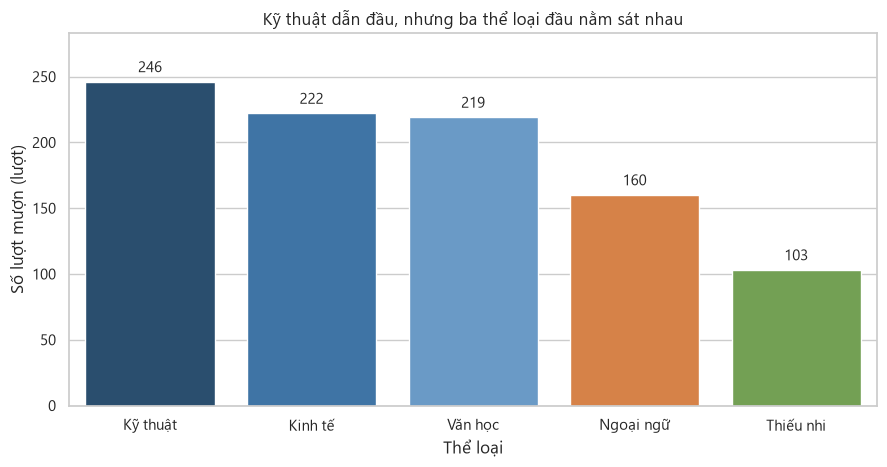

Nhận xét: Kỹ thuật cao nhất với 246 lượt, chỉ hơn Kinh tế 24 lượt. Thiếu nhi có 103 lượt, chưa bằng một nửa nhóm đầu. Nhu cầu vì vậy phân tán ở ba thể loại lớn; chỗ lệch mạnh hơn nằm ở tiền phạt, không nằm ở số lượt. Giới hạn: sáu phiếu ngày mượn không hợp lệ vẫn được đếm ở đây vì chúng là lượt mượn thật. Thứ hạng không đổi nếu bỏ chúng, như câu 22.


In [32]:
thu_tu_luot = dem_the_loai.index.tolist()
bang_ve = dem_the_loai.rename_axis("the_loai").reset_index(name="so_luot")
fig, ax = plt.subplots()
sns.barplot(
    data=bang_ve,
    x="the_loai",
    y="so_luot",
    order=thu_tu_luot,
    hue="the_loai",
    palette=GENRE_COLORS,
    dodge=False,
    legend=False,
    ax=ax,
)
# Vòng lặp này chỉ ghi số lên 5 cột, không duyệt từng phiếu.
for cot, chieu_cao in enumerate(dem_the_loai.loc[thu_tu_luot].to_numpy()):
    ax.text(cot, chieu_cao + dem_the_loai.max() * 0.02, f"{int(chieu_cao)}", ha="center", va="bottom")
ax.set_title("Kỹ thuật dẫn đầu, nhưng ba thể loại đầu nằm sát nhau")
ax.set_xlabel("Thể loại")
ax.set_ylabel("Số lượt mượn (lượt)")
ax.set_ylim(0, dem_the_loai.max() * 1.15)
fig.tight_layout()
plt.show()
print(
    f"Nhận xét: {dem_the_loai.index[0]} cao nhất với {int(dem_the_loai.iloc[0])} lượt, "
    f"chỉ hơn {dem_the_loai.index[1]} {int(dem_the_loai.iloc[0] - dem_the_loai.iloc[1])} lượt. "
    f"{dem_the_loai.index[-1]} có {int(dem_the_loai.iloc[-1])} lượt, chưa bằng một nửa nhóm đầu. "
    "Nhu cầu vì vậy phân tán ở ba thể loại lớn; chỗ lệch mạnh hơn nằm ở tiền phạt, không nằm ở số lượt. "
    "Giới hạn: sáu phiếu ngày mượn không hợp lệ vẫn được đếm ở đây vì chúng là lượt mượn thật. Thứ hạng không đổi nếu bỏ chúng, như câu 22."
)


### Câu 30. Box plot số ngày mượn theo thể loại, chỉ phiếu đã trả và hợp lệ


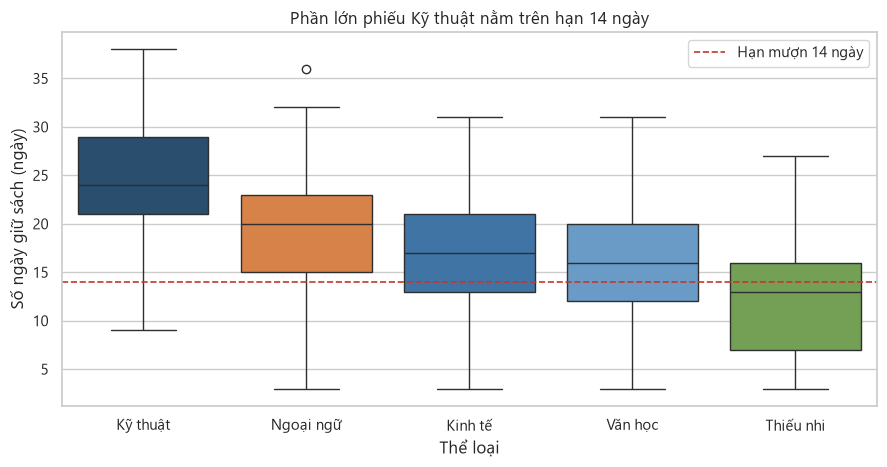

Nhận xét: Hộp Kỹ thuật nằm cao hơn các nhóm còn lại và cận dưới của nó đã vượt 14 ngày, nên quá hạn là tình trạng phổ biến của nhóm này chứ không phải vài điểm lẻ. Thiếu nhi có trung vị dưới hạn. Điểm ngoài râu hộp không tự động là lỗi dữ liệu. Râu là mốc 1,5 IQR của từng nhóm. Mọi phiếu trong biểu đồ đã khớp hiệu hai ngày và khớp công thức phạt, nên điểm nằm ngoài râu là lượt mượn dài nhưng còn bằng chứng hợp lệ. Giới hạn: sáu phiếu đã trả nhưng ngày mượn là 31/02/2024 không vào biểu đồ vì không kiểm được hiệu ngày.


In [33]:
thu_tu_hop = tu_phan_vi.index.tolist()
fig, ax = plt.subplots()
sns.boxplot(
    data=df_clean.loc[hop_le],
    x="the_loai",
    y="so_ngay_muon",
    order=thu_tu_hop,
    hue="the_loai",
    palette=GENRE_COLORS,
    dodge=False,
    legend=False,
    ax=ax,
)
ax.axhline(14, color="#c0392b", linestyle="--", linewidth=1.2, label="Hạn mượn 14 ngày")
ax.set_title("Phần lớn phiếu Kỹ thuật nằm trên hạn 14 ngày")
ax.set_xlabel("Thể loại")
ax.set_ylabel("Số ngày giữ sách (ngày)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()
print(
    "Nhận xét: Hộp Kỹ thuật nằm cao hơn các nhóm còn lại và cận dưới của nó đã vượt 14 ngày, "
    "nên quá hạn là tình trạng phổ biến của nhóm này chứ không phải vài điểm lẻ. "
    "Thiếu nhi có trung vị dưới hạn. "
    "Điểm ngoài râu hộp không tự động là lỗi dữ liệu. Râu là mốc 1,5 IQR của từng nhóm. "
    "Mọi phiếu trong biểu đồ đã khớp hiệu hai ngày và khớp công thức phạt, nên điểm nằm ngoài râu là lượt mượn dài nhưng còn bằng chứng hợp lệ. "
    "Giới hạn: sáu phiếu đã trả nhưng ngày mượn là 31/02/2024 không vào biểu đồ vì không kiểm được hiệu ngày."
)


### Câu 31. Đường số lượt mượn theo tháng


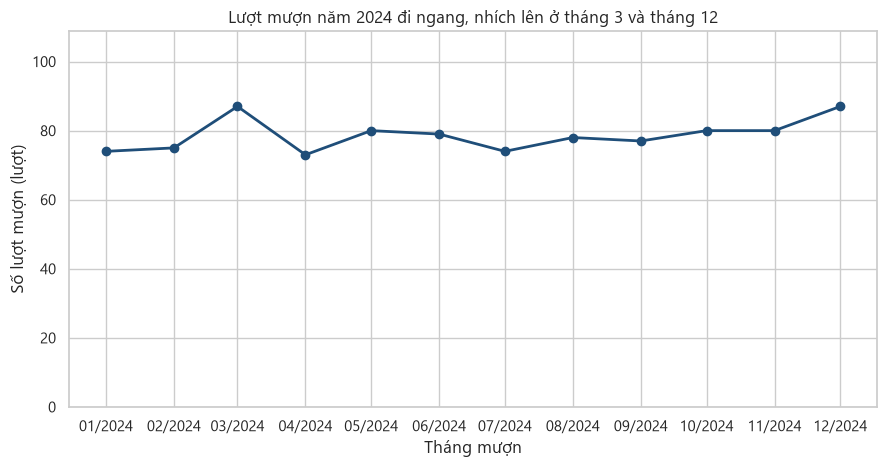

Nhận xét: Cả 12 tháng đều có sách được mượn, từ 73 đến 87 lượt. Cao nhất ở 03/2024, 12/2024; thấp nhất ở 04/2024. Chênh lệch khoảng hơn mười lượt, nên không thấy một mùa nào đứt gãy. Giới hạn: 6 phiếu có ngày mượn không tồn tại đứng ngoài đường. Trục thời gian vì thế đủ tháng nhưng tổng đường này nhỏ hơn tổng phiếu của thư viện.


In [34]:
fig, ax = plt.subplots()
ax.plot(luot_thang.index, luot_thang.to_numpy(), marker="o", color="#1f4e79", linewidth=2)
ax.set_xticks(luot_thang.index)
ax.set_xticklabels(luot_thang.index.strftime("%m/%Y"))
ax.set_title("Lượt mượn năm 2024 đi ngang, nhích lên ở tháng 3 và tháng 12")
ax.set_xlabel("Tháng mượn")
ax.set_ylabel("Số lượt mượn (lượt)")
ax.set_ylim(0, luot_thang.max() * 1.25)
fig.tight_layout()
plt.show()
thang_cao = luot_thang[luot_thang.eq(luot_thang.max())].index.strftime("%m/%Y").tolist()
thang_thap = luot_thang.idxmin().strftime("%m/%Y")
print(
    f"Nhận xét: Cả 12 tháng đều có sách được mượn, từ {int(luot_thang.min())} đến {int(luot_thang.max())} lượt. "
    f"Cao nhất ở {', '.join(thang_cao)}; thấp nhất ở {thang_thap}. "
    "Chênh lệch khoảng hơn mười lượt, nên không thấy một mùa nào đứt gãy. "
    "Giới hạn: 6 phiếu có ngày mượn không tồn tại đứng ngoài đường. Trục thời gian vì thế đủ tháng nhưng tổng đường này nhỏ hơn tổng phiếu của thư viện."
)


### Câu 32. Tỷ lệ phiếu Đang mượn theo cơ sở


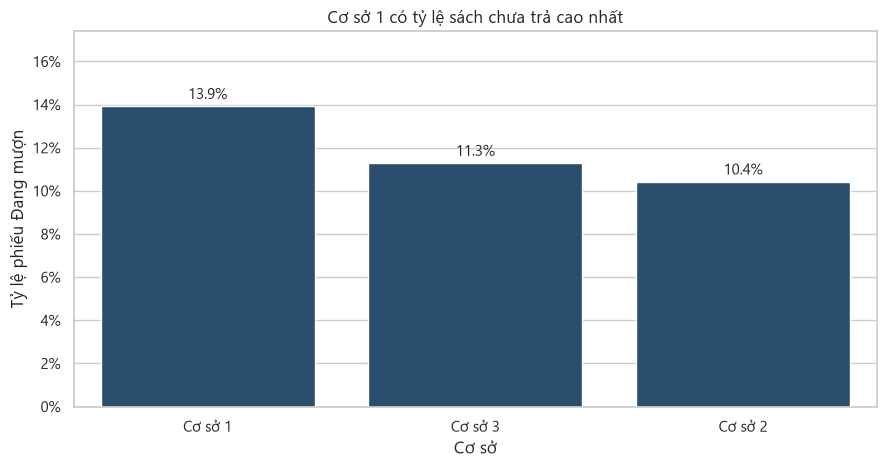

Nhận xét: Biểu đồ tỷ lệ chia số phiếu đang mượn cho tổng phiếu của chính cơ sở đó. Cơ sở 1 lớn nhất nên đương nhiên có nhiều phiếu đang mở hơn nếu chỉ đếm số. Tỷ lệ cho thấy Cơ sở 3 cao hơn Cơ sở 2, trong khi số tuyệt đối thì ngược lại. Giới hạn: phiếu đang mượn là trạng thái tại thời điểm cắt dữ liệu, không phải bằng chứng sách bị mất. Các cơ sở có thể được chốt sổ không cùng một ngày.


In [35]:
bang_ty_le = bang_trang_thai[["ty_le_dang_muon"]].reset_index()
fig, ax = plt.subplots()
sns.barplot(
    data=bang_ty_le,
    x="co_so",
    y="ty_le_dang_muon",
    order=bang_ty_le["co_so"].tolist(),
    color="#1f4e79",
    ax=ax,
)
ax.bar_label(ax.containers[0], labels=[f"{value:.1%}" for value in bang_ty_le["ty_le_dang_muon"]], padding=3)
ax.set_title("Cơ sở 1 có tỷ lệ sách chưa trả cao nhất")
ax.set_xlabel("Cơ sở")
ax.set_ylabel("Tỷ lệ phiếu Đang mượn")
ax.set_ylim(0, bang_ty_le["ty_le_dang_muon"].max() * 1.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _position: f"{value:.0%}"))
fig.tight_layout()
plt.show()
print(
    "Nhận xét: Biểu đồ tỷ lệ chia số phiếu đang mượn cho tổng phiếu của chính cơ sở đó. "
    "Cơ sở 1 lớn nhất nên đương nhiên có nhiều phiếu đang mở hơn nếu chỉ đếm số. "
    "Tỷ lệ cho thấy Cơ sở 3 cao hơn Cơ sở 2, trong khi số tuyệt đối thì ngược lại. "
    "Giới hạn: phiếu đang mượn là trạng thái tại thời điểm cắt dữ liệu, không phải bằng chứng sách bị mất. Các cơ sở có thể được chốt sổ không cùng một ngày."
)


### Câu 33. Giới hạn cần nhớ khi đọc bốn biểu đồ


In [36]:
gioi_han = pd.DataFrame(
    [
        ["Cột theo thể loại", "Thứ hạng lượt mượn", "Sáu ngày mượn không hợp lệ vẫn được tính là một lượt"],
        ["Box plot số ngày", "Nhóm nào giữ sách lâu", "Chưa gồm 6 phiếu đã trả nhưng không kiểm được hiệu ngày"],
        ["Đường theo tháng", "Mùa nào mượn nhiều", "6 phiếu 31/02/2024 không có tháng; không được cộng vào tháng 2"],
        ["Tỷ lệ đang mượn", "Cơ sở nào còn nhiều sách ngoài kệ hơn", "Chưa biết các cơ sở có cùng ngày chốt dữ liệu hay không"],
    ],
    columns=["bieu_do", "cau_hoi", "gioi_han"],
)
display(gioi_han)
print(
    "Nhận xét: Bốn biểu đồ đã có tiêu đề, nhãn trục, đơn vị, thứ tự nhóm và màu gắn với thể loại. "
    "Thứ tự cột và hộp đi theo đại lượng cần so, không theo bảng chữ cái. Đường tháng đi theo thời gian."
)


,bieu_do,cau_hoi,gioi_han
0,Cột theo thể loại,Thứ hạng lượt mượn,Sáu ngày mượn không hợp lệ vẫn được tính là mộ...
1,Box plot số ngày,Nhóm nào giữ sách lâu,Chưa gồm 6 phiếu đã trả nhưng không kiểm được ...
2,Đường theo tháng,Mùa nào mượn nhiều,6 phiếu 31/02/2024 không có tháng; không được ...
3,Tỷ lệ đang mượn,Cơ sở nào còn nhiều sách ngoài kệ hơn,Chưa biết các cơ sở có cùng ngày chốt dữ liệu ...


Nhận xét: Bốn biểu đồ đã có tiêu đề, nhãn trục, đơn vị, thứ tự nhóm và màu gắn với thể loại. Thứ tự cột và hộp đi theo đại lượng cần so, không theo bảng chữ cái. Đường tháng đi theo thời gian.


## E. Kết luận và đề xuất

150–250 từ. Mỗi nhận định chính bám vào một bảng hoặc một biểu đồ ở trên.


### Câu 34, 35 và 36


In [37]:
ky_thuat_luot = int(dem_the_loai.loc["Kỹ thuật"])
tong_phieu = int(dem_the_loai.sum())
ty_trong_ky_thuat = ky_thuat_luot / tong_phieu
phat_da_tra = df_clean.loc[df_clean["trang_thai"].eq("Đã trả"), "tien_phat"].astype(float)
tong_phat = float(phat_da_tra.sum())
phat_ky_thuat = float(df_clean.loc[df_clean["trang_thai"].eq("Đã trả") & df_clean["the_loai"].eq("Kỹ thuật"), "tien_phat"].astype(float).sum())
ty_trong_phat = phat_ky_thuat / tong_phat
trung_vi_ky_thuat = float(tu_phan_vi.loc["Kỹ thuật", "trung_vi"])
trung_vi_thieu_nhi = float(tu_phan_vi.loc["Thiếu nhi", "trung_vi"])
phat_tb_ky_thuat = float(phat_the_loai.loc["Kỹ thuật", "tien_phat_trung_binh"])
so_tre = int((df_clean.loc[hop_le, "so_ngay_tre"].astype(float) > 0).sum())
so_hop_le = int(hop_le.sum())
ty_le_tre = so_tre / so_hop_le
trung_vi_0 = float(bang_gia_han.loc[0, "trung_vi"])
trung_vi_2 = float(bang_gia_han.loc[2, "trung_vi"])
so_dang_muon = int(df_clean["trang_thai"].eq("Đang mượn").sum())
so_ngay_loi = int(df_clean["ngay_muon"].isna().sum())

chuoi_co_d = int(df_raw.drop_duplicates()["tien_phat"].astype("string").str.contains("đ", na=False).sum())
tong_dung_chuoi = 4_043_000
tong_sai_chuoi = 4_043

ket_luan = (
    f"Hai phát hiện quan trọng nhất như sau. "
    f"Thứ nhất, Kỹ thuật có {ky_thuat_luot} trên {tong_phieu} lượt ({fmt_pct(ty_trong_ky_thuat * 100)}%) "
    f"nhưng chiếm {fmt_int(phat_ky_thuat)} đồng, tức {fmt_pct(ty_trong_phat * 100)}% tổng phạt "
    f"{fmt_int(tong_phat)} đồng của phiếu đã trả. Trung vị ngày giữ của phiếu Kỹ thuật đã trả và có ngày hợp lệ là "
    f"{trung_vi_ky_thuat:.0f} ngày, so với {trung_vi_thieu_nhi:.0f} ngày ở Thiếu nhi. "
    f"Tiền phạt trung bình mỗi phiếu đã trả của nhóm này là {fmt_int(phat_tb_ky_thuat)} đồng vì mức 7.000 đồng mỗi ngày. "
    f"Thứ hai, trả trễ là phổ biến: {so_tre} trên {so_hop_le} phiếu ({fmt_pct(ty_le_tre * 100)}%) vượt hạn 14 ngày. "
    f"Gia hạn đi cùng số ngày giữ, Spearman {fmt_pct(spearman, 2)}: "
    f"không gia hạn thì trung vị {trung_vi_0:.0f} ngày, gia hạn hai lần thì trung vị {trung_vi_2:.0f} ngày. "
    f"Tương quan không chứng minh nhân quả, vì nội quy cho phép gia hạn để giữ sách lâu hơn. "
    f"Vấn đề chất lượng nguy hiểm nhất là chuỗi phạt dạng 63.000 đ. Dấu chấm là dấu ngăn hàng nghìn. "
    f"Nếu đọc thành số thập phân, {chuoi_co_d} phiếu thu nhỏ đúng 1.000 lần, từ {fmt_int(tong_dung_chuoi)} đồng còn "
    f"{fmt_int(tong_sai_chuoi)} đồng, mà lệnh không báo lỗi. "
    f"Đề xuất: nhắc hạn trước ngày thứ 14 với sách Kỹ thuật và rà soát gia hạn của nhóm này. "
    f"Bằng chứng là trung vị {trung_vi_ky_thuat:.0f} ngày và {fmt_pct(ty_trong_phat * 100)}% tiền phạt. "
    f"Không suy ra bạn đọc nhóm này kém ý thức hơn, vì mức phạt mỗi ngày cao hơn nhóm 3.000 đồng. "
    f"Chưa tính {so_dang_muon} phiếu đang mượn và {so_ngay_loi} phiếu có ngày 31/02/2024."
)
so_tu = len(ket_luan.split())
print(ket_luan)
print(f"Số từ: {so_tu}")
assert 150 <= so_tu <= 250
assert ky_thuat_luot == 246
assert int(phat_ky_thuat) == 14_455_000
assert so_tre == 581


Hai phát hiện quan trọng nhất như sau. Thứ nhất, Kỹ thuật có 246 trên 950 lượt (25,9%) nhưng chiếm 14.455.000 đồng, tức 60,8% tổng phạt 23.771.000 đồng của phiếu đã trả. Trung vị ngày giữ của phiếu Kỹ thuật đã trả và có ngày hợp lệ là 24 ngày, so với 13 ngày ở Thiếu nhi. Tiền phạt trung bình mỗi phiếu đã trả của nhóm này là 72.275 đồng vì mức 7.000 đồng mỗi ngày. Thứ hai, trả trễ là phổ biến: 581 trên 827 phiếu (70,3%) vượt hạn 14 ngày. Gia hạn đi cùng số ngày giữ, Spearman 0,76: không gia hạn thì trung vị 12 ngày, gia hạn hai lần thì trung vị 28 ngày. Tương quan không chứng minh nhân quả, vì nội quy cho phép gia hạn để giữ sách lâu hơn. Vấn đề chất lượng nguy hiểm nhất là chuỗi phạt dạng 63.000 đ. Dấu chấm là dấu ngăn hàng nghìn. Nếu đọc thành số thập phân, 105 phiếu thu nhỏ đúng 1.000 lần, từ 4.043.000 đồng còn 4.043 đồng, mà lệnh không báo lỗi. Đề xuất: nhắc hạn trước ngày thứ 14 với sách Kỹ thuật và rà soát gia hạn của nhóm này. Bằng chứng là trung vị 24 ngày và 60,8% tiền phạt. Kh

## Tự kiểm tra trước khi nộp


In [38]:
kiem_tra = {
    "ma_the du 4 ky tu, ke ca so 0 dau": bool(doc_lai["ma_the"].str.fullmatch(r"\d{4}").all()),
    "df_raw con nguyen va file tho khong bi ghi de": hashlib.sha256(DATA_RAW.read_bytes()).hexdigest() == RAW_HASH and len(df_raw) == 980,
    "ma_phieu duy nhat sau khi bo trung hoan toan": bool(df_clean["ma_phieu"].is_unique),
    "con 5 the loai va 3 co so": df_clean["the_loai"].nunique() == 5 and df_clean["co_so"].nunique() == 3,
    "ngay la datetime, tien va so ngay la so": str(df_clean["ngay_muon"].dtype).startswith("datetime64") and str(df_clean["tien_phat"].dtype) == "Int64",
    "phieu dang muon khong co ngay tra hoac tien phat gia": int(df_clean.loc[df_clean["trang_thai"].eq("Đang mượn"), "tien_phat"].notna().sum()) == 0,
    "phieu da tra co ngay hop le vuot hai kiem chung": int(lech.sum()) == 0,
    "co doi chieu NumPy voi Pandas": int(doi_chieu_dem["chenh"].abs().max()) == 0,
    "da ghi data/muon_sach_clean.csv bang duong dan tuong doi": DATA_CLEAN.exists(),
}
bang_kiem = pd.Series(kiem_tra, name="dat").to_frame()
display(bang_kiem)
assert bool(bang_kiem["dat"].all())
print("Notebook đã qua các kiểm tra chính. Hãy Restart Kernel and Run All Cells một lần nữa trên máy nộp bài.")


,dat
"ma_the du 4 ky tu, ke ca so 0 dau",True
df_raw con nguyen va file tho khong bi ghi de,True
ma_phieu duy nhat sau khi bo trung hoan toan,True
con 5 the loai va 3 co so,True
"ngay la datetime, tien va so ngay la so",True
phieu dang muon khong co ngay tra hoac tien phat gia,True
phieu da tra co ngay hop le vuot hai kiem chung,True
co doi chieu NumPy voi Pandas,True
da ghi data/muon_sach_clean.csv bang duong dan tuong doi,True


Notebook đã qua các kiểm tra chính. Hãy Restart Kernel and Run All Cells một lần nữa trên máy nộp bài.
